## Loading data

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import sys
import os
import random
from loguru import logger

sys.path.append('..')  # Add parent directory

from config import INTENDED_SAMPLING_INTERVALS_SECONDS


In [49]:
notebook_dir = os.getcwd()
data_dir = os.path.dirname(os.path.dirname(notebook_dir))
appended_dir = os.path.join(data_dir, 'appended')
data_path = os.path.join(appended_dir, 'incl_noon_reports.csv')

df = pd.read_csv(data_path, parse_dates=['utc_timestamp'])

df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'], format='ISO8601')

C:\Users\Augus\AppData\Local\Temp\ipykernel_17476\3297968600.py:6: DtypeWarning: Columns (0: value) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, parse_dates=['utc_timestamp'])


In [50]:
qid_mappings_dict = df[['quantity_name', 'qid_mapping', 'source_name']].drop_duplicates()
qid_mappings_dict

,quantity_name,qid_mapping,source_name
0,Vessel External Conditions Eastward Sea Water ...,4::0::8::0_1::1::0::7::0_56::0::3::0_8,Provider S
1,Vessel External Conditions Sea Water Temperature,4::0::8::0_1::1::0::7::0_4::0::12::0_8,Provider S
2,Vessel External Conditions Northward Sea Water...,4::0::4::0_1::1::0::7::0_56::0::4::0_8,Provider MB
3,Vessel External Conditions Wave Significant He...,4::0::4::0_1::1::0::7::0_45::0::1::0_8,Provider MB
4,Vessel External Conditions Eastward Wind Velocity,4::0::8::0_1::1::0::7::0_56::0::5::0_8,Provider S
5,Vessel External Conditions Swell Significant H...,4::0::4::0_1::1::0::7::0_45::0::2::0_8,Provider MB
6,Vessel External Conditions Eastward Sea Water ...,4::0::4::0_1::1::0::7::0_56::0::3::0_8,Provider MB
7,Vessel External Conditions Wind True Angle,4::0::4::0_1::1::0::7::0_2::0::15::21_8,Provider MB
8,Vessel External Conditions Wave Period,4::0::8::0_1::1::0::7::0_40::0::2::0_8,Provider S
9,Vessel External Conditions Wind True Speed,4::0::4::0_1::1::0::7::0_1::0::4::21_8,Provider MB


In [51]:
df.shape

(52974978, 7)

In [52]:
df.head()

,utc_timestamp,qid_mapping,value,quantity_name,source_name,unit,time_delta_sec
0,2024-01-01 00:00:00+00:00,4::0::8::0_1::1::0::7::0_56::0::3::0_8,-0.4,Vessel External Conditions Eastward Sea Water ...,Provider S,m/s,NaN
1,2024-01-01 00:00:00+00:00,4::0::8::0_1::1::0::7::0_4::0::12::0_8,6.0,Vessel External Conditions Sea Water Temperature,Provider S,Â°C,NaN
2,2024-01-01 00:00:00+00:00,4::0::4::0_1::1::0::7::0_56::0::4::0_8,0.0,Vessel External Conditions Northward Sea Water...,Provider MB,m/s,NaN
3,2024-01-01 00:00:00+00:00,4::0::4::0_1::1::0::7::0_45::0::1::0_8,2.7,Vessel External Conditions Wave Significant He...,Provider MB,m,NaN
4,2024-01-01 00:00:00+00:00,4::0::8::0_1::1::0::7::0_56::0::5::0_8,0.5391,Vessel External Conditions Eastward Wind Velocity,Provider S,m/s,NaN


In [53]:
df.tail()

,utc_timestamp,qid_mapping,value,quantity_name,source_name,unit,time_delta_sec
52974973,2024-12-31 23:59:45.021000+00:00,3::0::1::0_1::1::0::2::0_11::0::4::0_8,0.0,Vessel Hull MidS Draft,Control Alarm Monitoring System,m,15.009
52974974,2024-12-31 23:59:45.021000+00:00,3::0::1::0_1::1::0::2::0_11::0::2::0_8,0.0,Vessel Hull Aft Draft,Control Alarm Monitoring System,m,15.009
52974975,2024-12-31 23:59:45.021000+00:00,3::0::1::0_1::2::0::8::0_1::0::6::0_8,0.0,Main Engine Rotational Speed,Control Alarm Monitoring System,rpm,15.009
52974976,2024-12-31 23:59:45.021000+00:00,3::0::1::0_1::1::0::2::0_11::0::3::0_8,0.0,Vessel Hull MidP Draft,Control Alarm Monitoring System,m,15.009
52974977,2024-12-31 23:59:45.021000+00:00,3::0::1::0_1::1::0::2::0_11::0::1::0_8,0.0,Vessel Hull Fore Draft,Control Alarm Monitoring System,m,15.009


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52974978 entries, 0 to 52974977
Data columns (total 7 columns):
 #   Column          Dtype              
---  ------          -----              
 0   utc_timestamp   datetime64[us, UTC]
 1   qid_mapping     str                
 2   value           object             
 3   quantity_name   str                
 4   source_name     str                
 5   unit            str                
 6   time_delta_sec  float64            
dtypes: datetime64[us, UTC](1), float64(1), object(1), str(4)
memory usage: 2.8+ GB


In [55]:
df.describe()

,time_delta_sec
count,5.297492e+07
mean,3.338154e+01
std,2.046881e+03
min,0.000000e+00
25%,1.499600e+01
50%,1.500000e+01
75%,1.500500e+01
max,5.356800e+06


In [56]:
# set a random seed for reproducibility
np.random.seed(42)

In [57]:
# filter out all qids where the source name contain "provider" or "Noon Report"

sensor_only_qid_dict = qid_mappings_dict[~qid_mappings_dict['source_name'].str.contains('provider|Noon Report', case=False)]
sensor_only_qid_dict

,quantity_name,qid_mapping,source_name
14,cumulative_fouling_penalty_index,5::0::0::0_0::0::0::0::0_0::0::0::0_2,calculated
15,delta_fouling_penalty_index,5::0::0::0_0::0::0::0::0_0::0::0::0_1,calculated
16,Vessel External Conditions Wind Relative Angle,2::0::1::0_1::1::0::7::0_2::0::15::22_8,Instrument Anemometer
17,Vessel External Conditions Wind Relative Speed,2::0::1::0_1::1::0::7::0_1::0::4::22_8,Instrument Anemometer
18,Vessel Hull Through Water Longitudinal Speed,2::0::7::0_1::1::0::2::0_1::0::5::11_8,Instrument Speedlog
19,is_in_voyage,5::0::0::0_0::0::0::0::0_0::0::0::0_3,calculated
20,Vessel Hull Over Ground Speed,2::0::6::1_1::1::0::2::0_1::0::1::0_8,Instrument GPS 1
21,voyage_duration_hours,5::0::0::0_0::0::0::0::0_0::0::0::0_5,calculated
22,temporary_voyage_id,5::0::0::0_0::0::0::0::0_0::0::0::0_4,calculated
23,actual_voyage_id,5::0::0::0_0::0::0::0::0_0::0::0::0_6,calculated


In [58]:
# take all qids where the source name contains "provider"
weather_only_qid_dict = qid_mappings_dict[qid_mappings_dict['source_name'].str.contains('provider', case=False)]
weather_only_qid_dict

,quantity_name,qid_mapping,source_name
0,Vessel External Conditions Eastward Sea Water ...,4::0::8::0_1::1::0::7::0_56::0::3::0_8,Provider S
1,Vessel External Conditions Sea Water Temperature,4::0::8::0_1::1::0::7::0_4::0::12::0_8,Provider S
2,Vessel External Conditions Northward Sea Water...,4::0::4::0_1::1::0::7::0_56::0::4::0_8,Provider MB
3,Vessel External Conditions Wave Significant He...,4::0::4::0_1::1::0::7::0_45::0::1::0_8,Provider MB
4,Vessel External Conditions Eastward Wind Velocity,4::0::8::0_1::1::0::7::0_56::0::5::0_8,Provider S
5,Vessel External Conditions Swell Significant H...,4::0::4::0_1::1::0::7::0_45::0::2::0_8,Provider MB
6,Vessel External Conditions Eastward Sea Water ...,4::0::4::0_1::1::0::7::0_56::0::3::0_8,Provider MB
7,Vessel External Conditions Wind True Angle,4::0::4::0_1::1::0::7::0_2::0::15::21_8,Provider MB
8,Vessel External Conditions Wave Period,4::0::8::0_1::1::0::7::0_40::0::2::0_8,Provider S
9,Vessel External Conditions Wind True Speed,4::0::4::0_1::1::0::7::0_1::0::4::21_8,Provider MB


In [59]:
df['qid_mapping'].unique()

<StringArray>
[ '4::0::8::0_1::1::0::7::0_56::0::3::0_8',
  '4::0::8::0_1::1::0::7::0_4::0::12::0_8',
  '4::0::4::0_1::1::0::7::0_56::0::4::0_8',
  '4::0::4::0_1::1::0::7::0_45::0::1::0_8',
  '4::0::8::0_1::1::0::7::0_56::0::5::0_8',
  '4::0::4::0_1::1::0::7::0_45::0::2::0_8',
  '4::0::4::0_1::1::0::7::0_56::0::3::0_8',
 '4::0::4::0_1::1::0::7::0_2::0::15::21_8',
  '4::0::8::0_1::1::0::7::0_40::0::2::0_8',
  '4::0::4::0_1::1::0::7::0_1::0::4::21_8',
  '4::0::8::0_1::1::0::7::0_56::0::4::0_8',
  '4::0::8::0_1::1::0::7::0_45::0::1::0_8',
  '4::0::8::0_1::1::0::7::0_56::0::6::0_8',
 '4::0::8::0_1::1::0::7::0_2::0::18::21_8',
   '5::0::0::0_0::0::0::0::0_0::0::0::0_2',
   '5::0::0::0_0::0::0::0::0_0::0::0::0_1',
 '2::0::1::0_1::1::0::7::0_2::0::15::22_8',
  '2::0::1::0_1::1::0::7::0_1::0::4::22_8',
  '2::0::7::0_1::1::0::2::0_1::0::5::11_8',
   '5::0::0::0_0::0::0::0::0_0::0::0::0_3',
   '2::0::6::1_1::1::0::2::0_1::0::1::0_8',
   '5::0::0::0_0::0::0::0::0_0::0::0::0_5',
   '5::0::0::0_0::

## Sanity Check fouling proxy

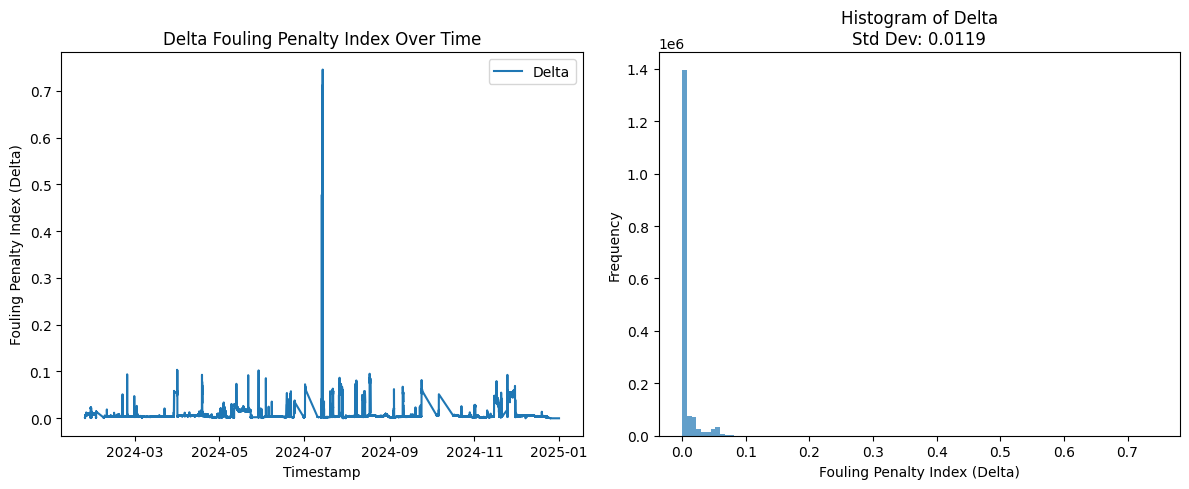

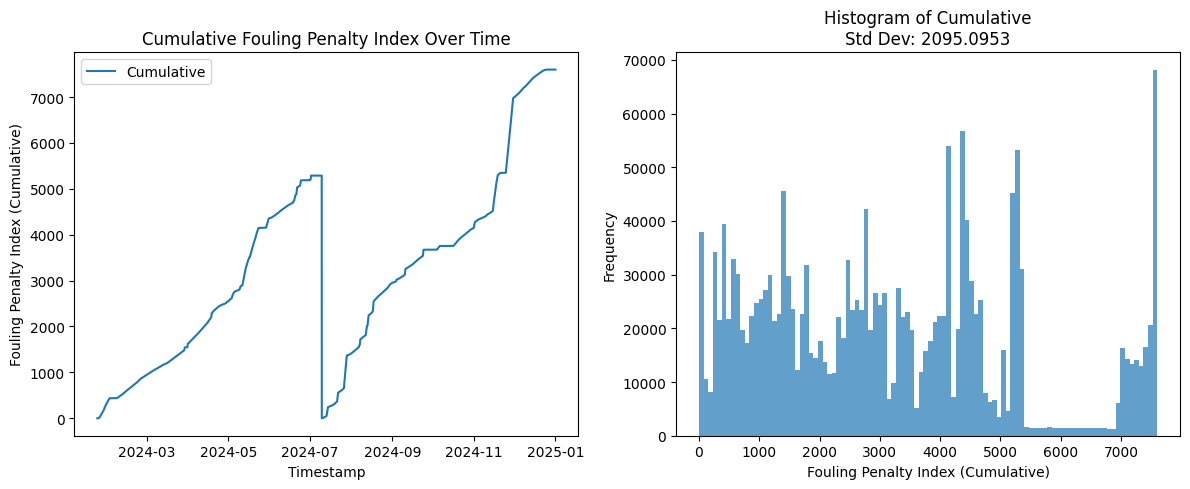

In [31]:
fouling_proxy_qids = {
#    "Water Temperature": "4::0::8::0_1::1::0::7::0_4::0::12::0_8",
#   "Speed Through Water": "2::0::7::0_1::1::0::2::0_1::0::5::11_8",
    "Delta": "5::0::0::0_0::0::0::0::0_0::0::0::0_1",
    "Cumulative": "5::0::0::0_0::0::0::0::0_0::0::0::0_2",
}

# for each of the key-value pairs, make a line graph and a histogram next to each other
for key, qid in fouling_proxy_qids.items():
    fouling_data = df[df['qid_mapping'] == qid].copy()
    
    if fouling_data.empty:
        print(f"Skipping '{key}': qid {qid} not found in df['qid_mapping']")
        continue
    
    fouling_data['value'] = pd.to_numeric(fouling_data['value'], errors='coerce')
    fouling_data = fouling_data.dropna(subset=['value']).sort_values('utc_timestamp')
    
    if fouling_data.empty:
        print(f"Skipping '{key}': qid {qid} has no numeric values")
        continue
    
    plt.figure(figsize=(12, 5))
    
    # Line graph
    plt.subplot(1, 2, 1)
    plt.plot(fouling_data['utc_timestamp'], fouling_data['value'], label=f'{key}')
    plt.xlabel('Timestamp')
    plt.ylabel(f'Fouling Penalty Index ({key})')
    plt.title(f'{key.capitalize()} Fouling Penalty Index Over Time')
    plt.legend()
    
    # Histogram
    plt.subplot(1, 2, 2)
    plt.hist(fouling_data['value'], bins=100, alpha=0.7)
    plt.xlabel(f'Fouling Penalty Index ({key})')
    plt.ylabel('Frequency')
    
    # Calculate and display standard deviation
    std_dev = fouling_data['value'].std()
    plt.title(f'Histogram of {key.capitalize()}\nStd Dev: {std_dev:.4f}')
    
    plt.tight_layout()
    plt.show()

## Check missing values for each variable for each day of the year compared with missing values for its provider

In [32]:
# check if all variables have data for all days in the whole dataset
def check_daily_distribution(df, var_qid, var_name):
    days = df['utc_timestamp'].dt.day.unique()
    expected_days = 365
    
    print(f"Variable Name: {var_name}")
    print(f"Expected days: {expected_days}")
    print(f"Actual days: {sorted(days)}")
    
    counts_per_day = df[df['qid_mapping'] == var_qid].groupby(df['utc_timestamp'].dt.dayofyear).size()
    plt.figure(figsize=(10, 5))
    counts_per_day.plot(kind='bar', width=1.0)
    plt.title(f'Data Points per Day for Variable Name {var_name}')
    plt.xlabel('Day of Year')
    plt.ylabel('Number of Data Points')
    plt.show()

def check_daily_source_distribution(df, provider_name):
    
    counts_per_day = df[df['source_name'] == provider_name].groupby(df['utc_timestamp'].dt.dayofyear).size()
    plt.figure(figsize=(10, 5))
    counts_per_day.plot(kind='bar', width=1.0)
    plt.title(f'Data Points per Day for Provider {provider_name}')
    plt.xlabel('Day of Year')
    plt.ylabel('Number of Data Points')
    plt.show()


Variable Name: Vessel External Conditions Eastward Sea Water Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


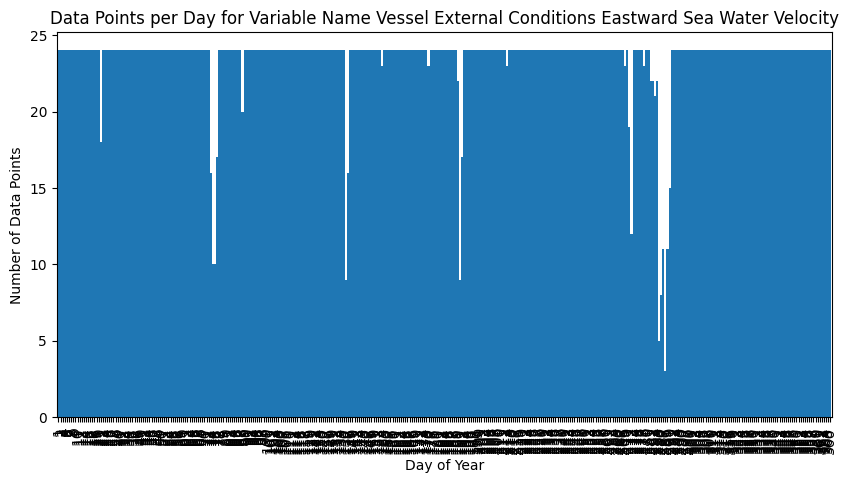

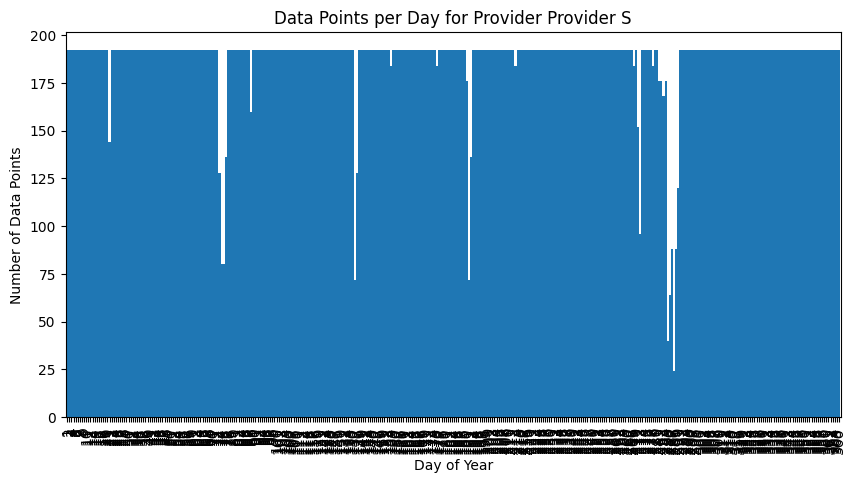

Variable Name: Vessel External Conditions Northward Wind Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


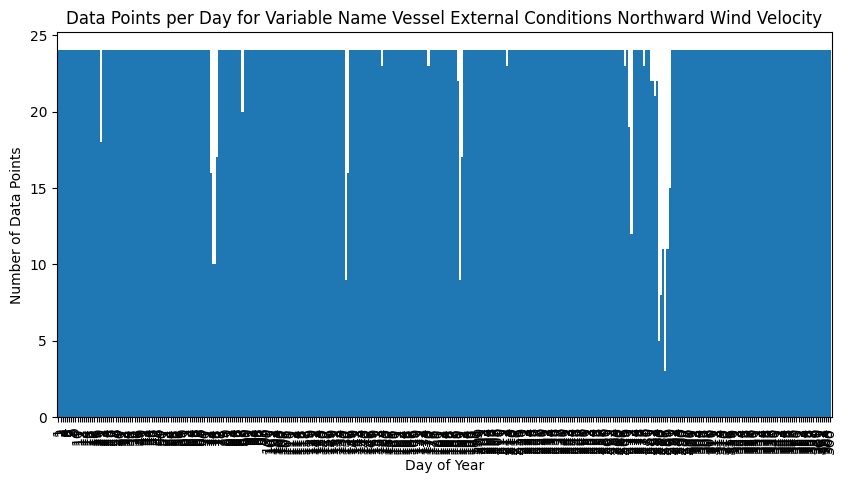

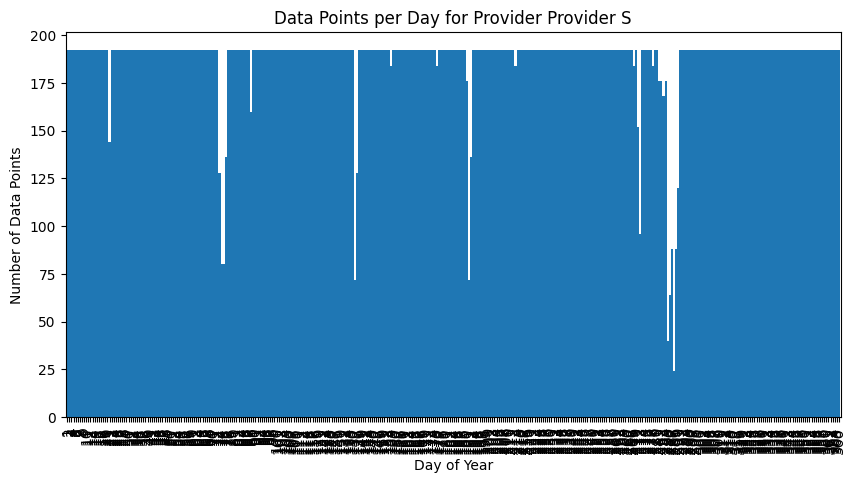

Variable Name: Vessel External Conditions Wave Significant Height
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


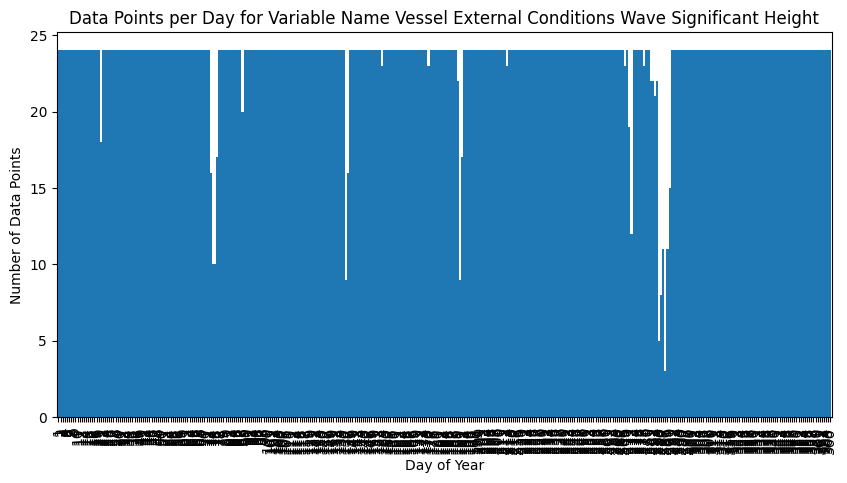

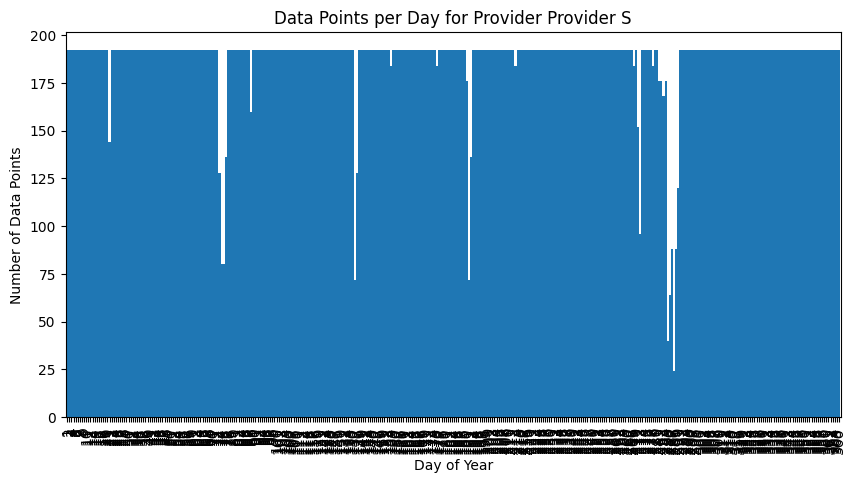

Variable Name: Vessel External Conditions Northward Sea Water Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


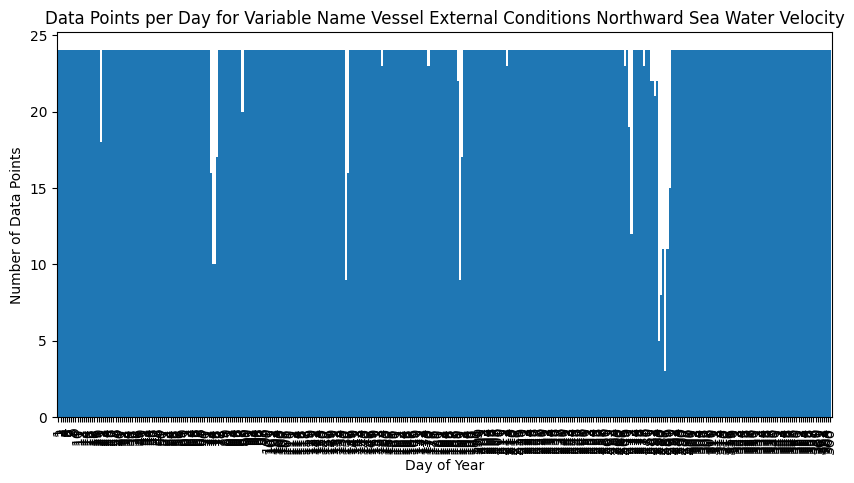

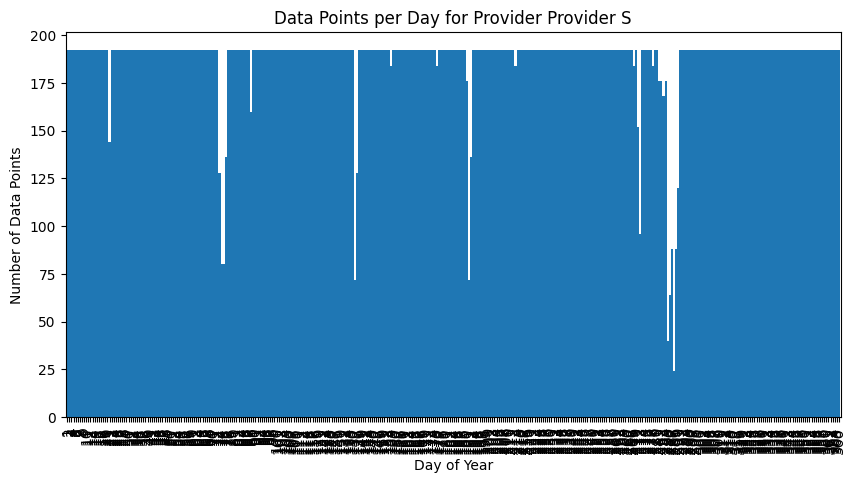

Variable Name: Vessel External Conditions Wind True Speed
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


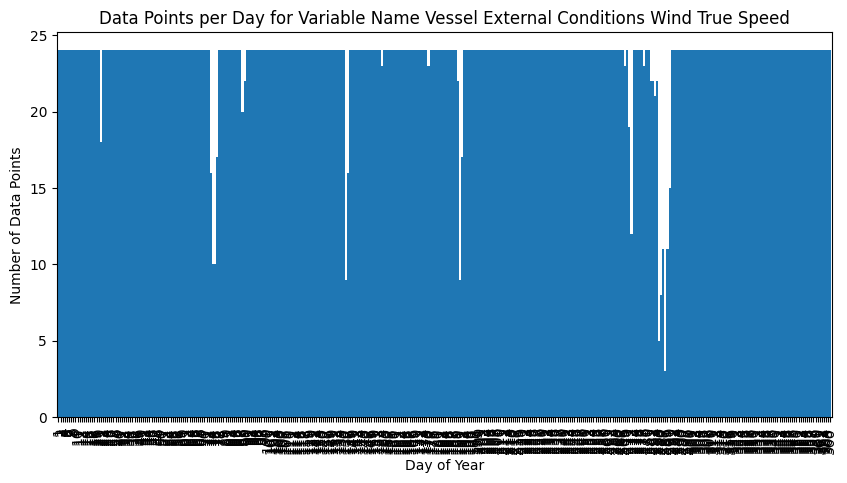

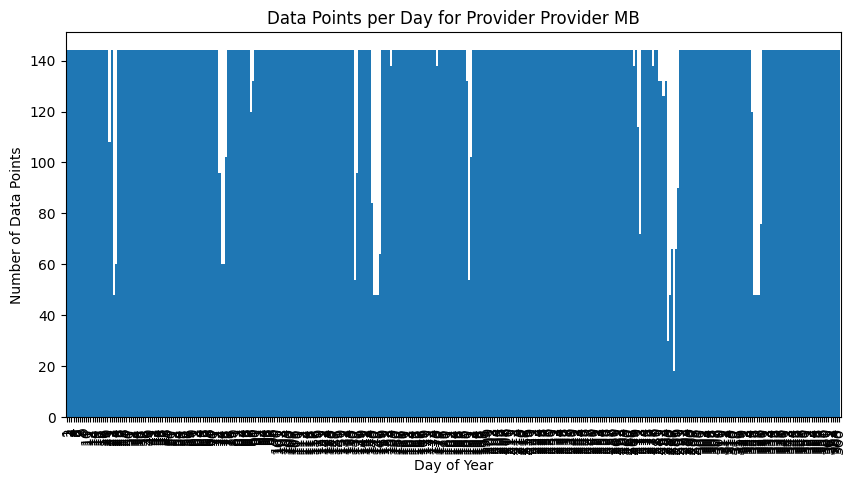

Variable Name: Vessel External Conditions Wave Period
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


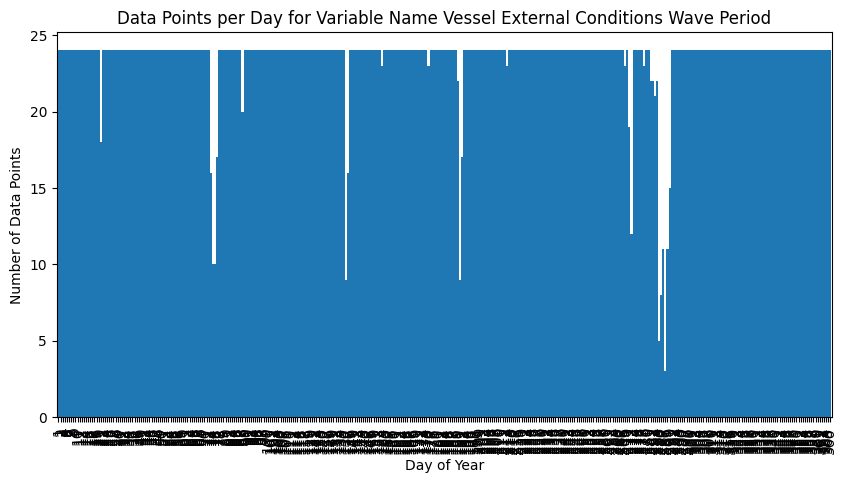

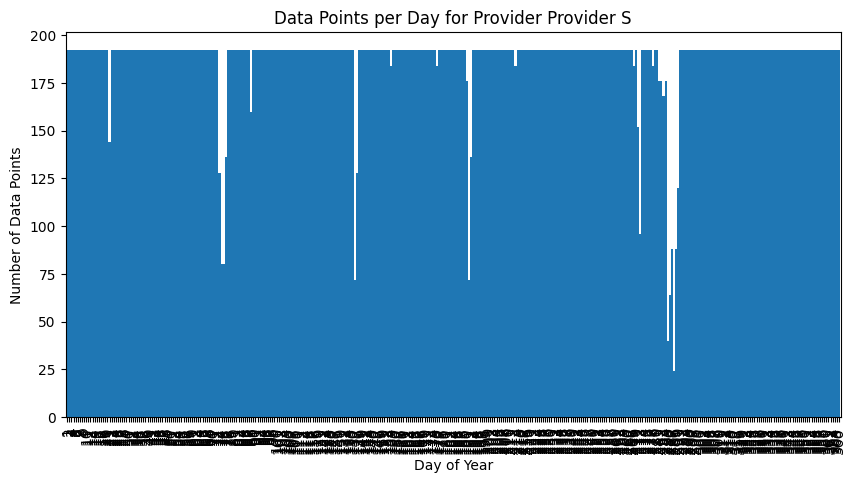

Variable Name: Vessel External Conditions Wave True Angle
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


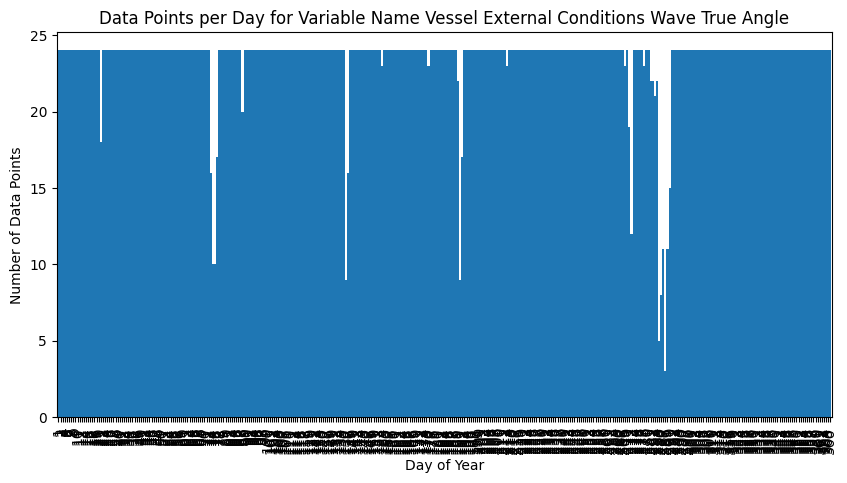

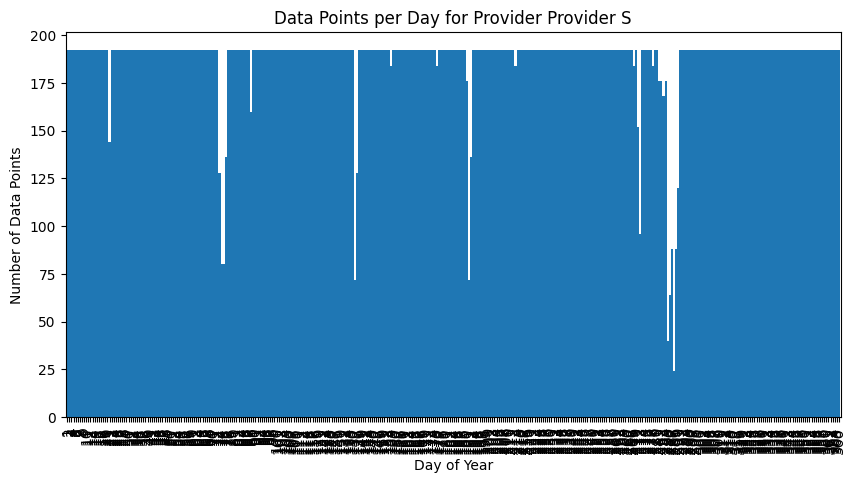

Variable Name: Vessel External Conditions Eastward Sea Water Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


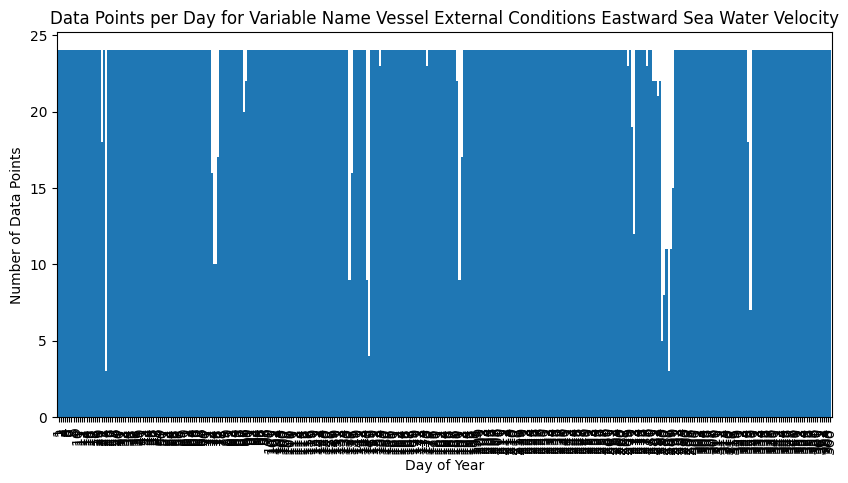

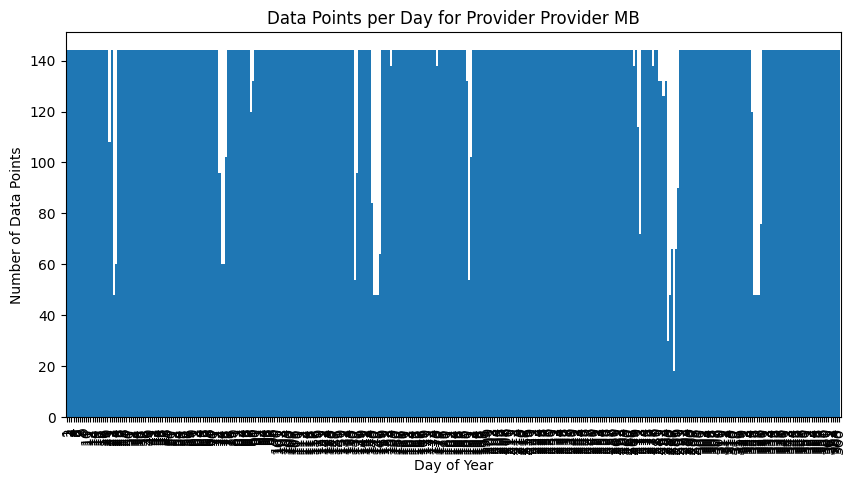

Variable Name: Vessel External Conditions Swell Significant Height
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


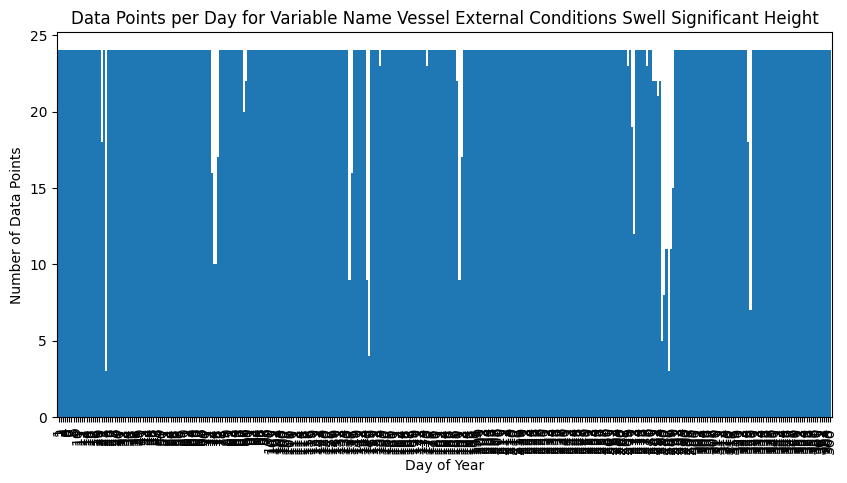

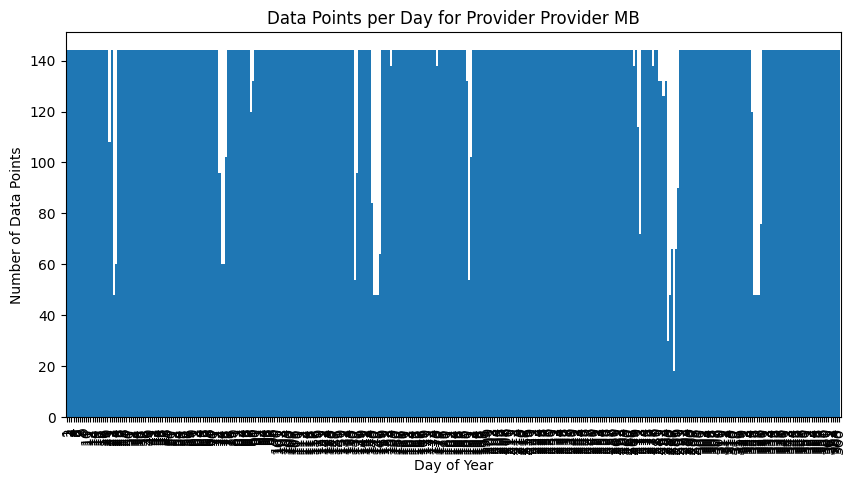

Variable Name: Vessel External Conditions Wind True Angle
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


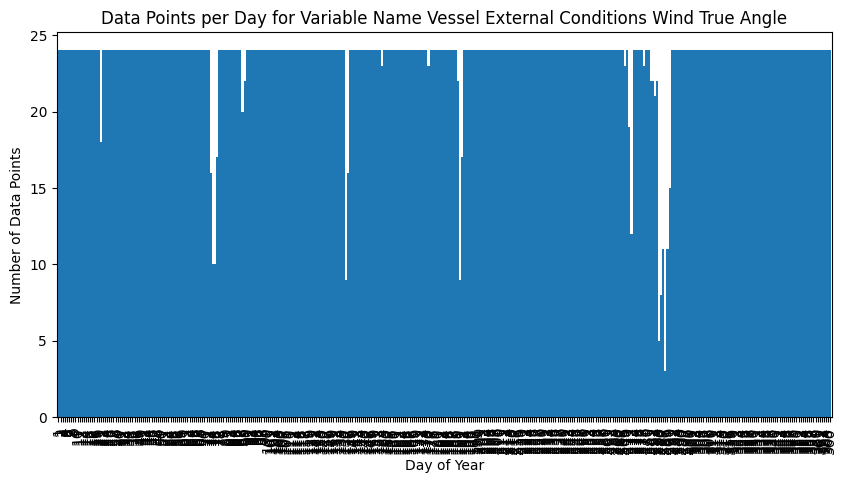

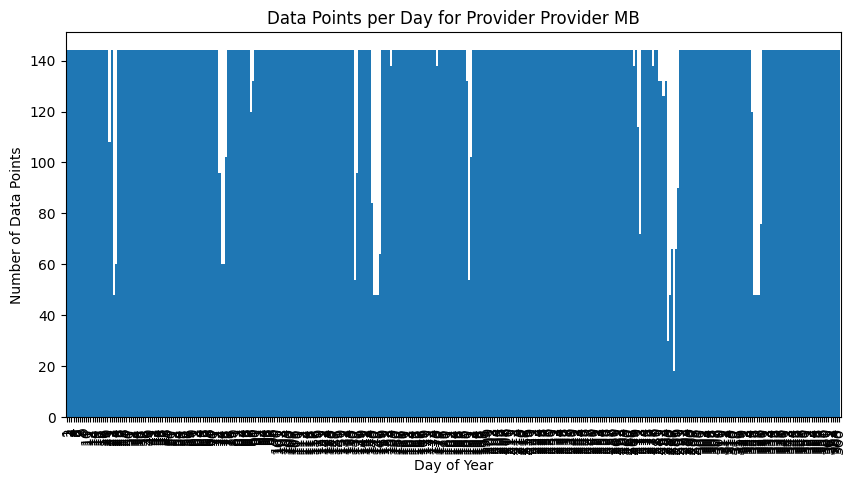

Variable Name: Vessel External Conditions Eastward Wind Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


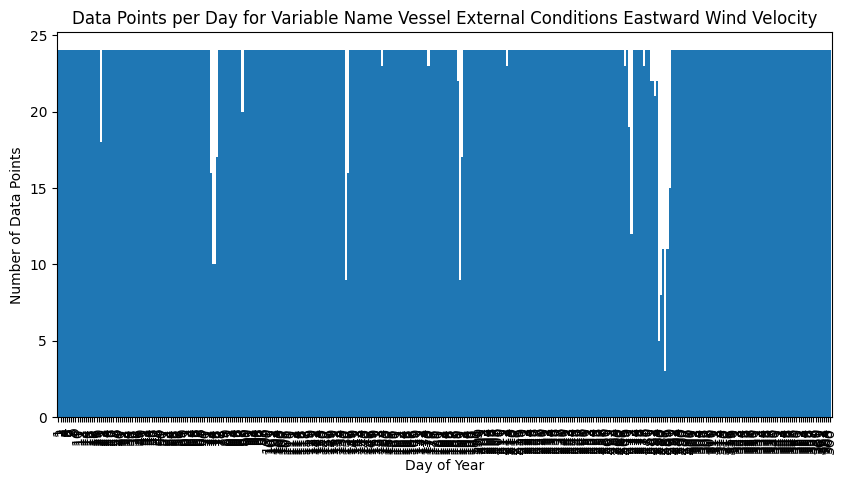

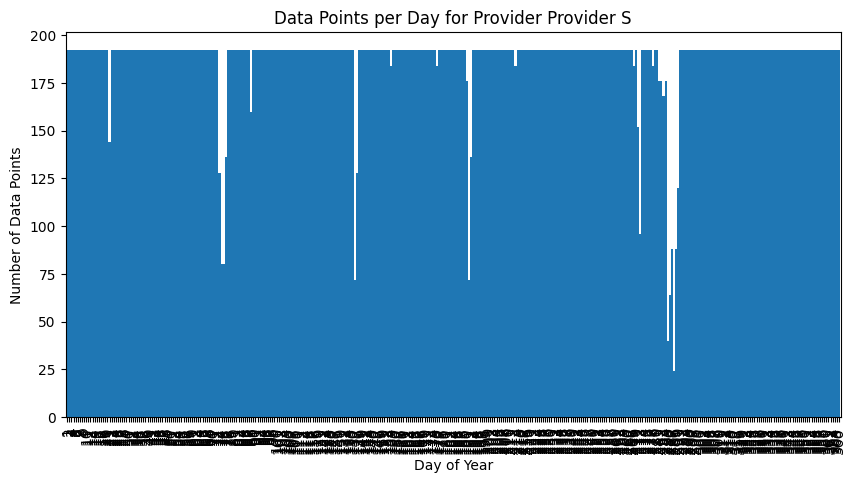

Variable Name: Vessel External Conditions Wave Significant Height
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


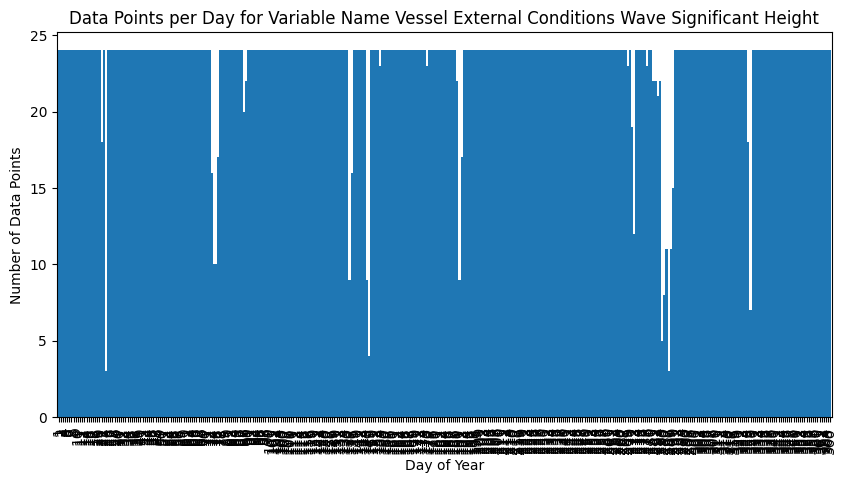

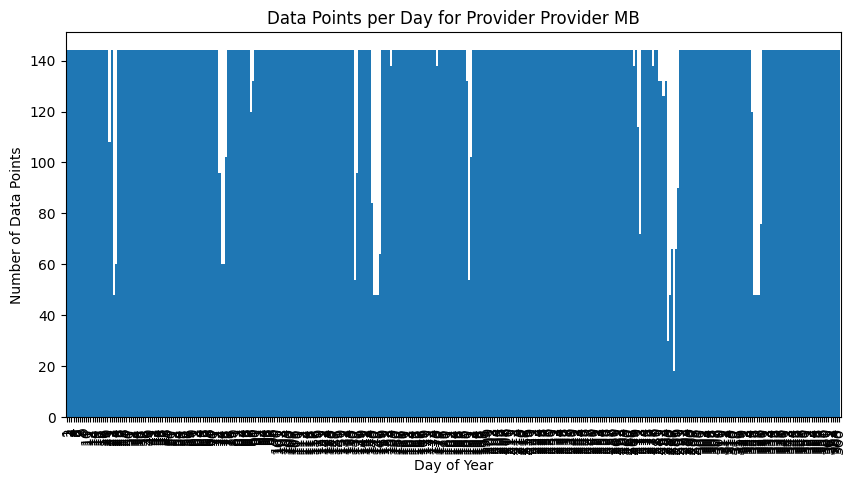

Variable Name: Vessel External Conditions Northward Sea Water Velocity
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


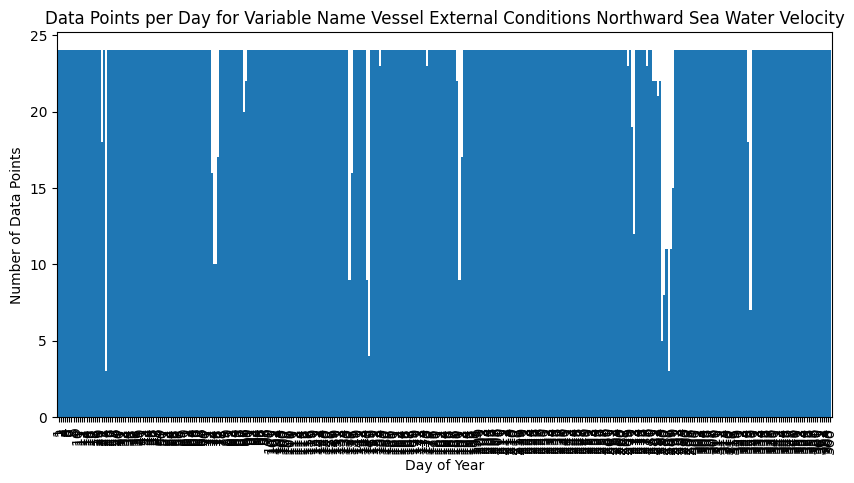

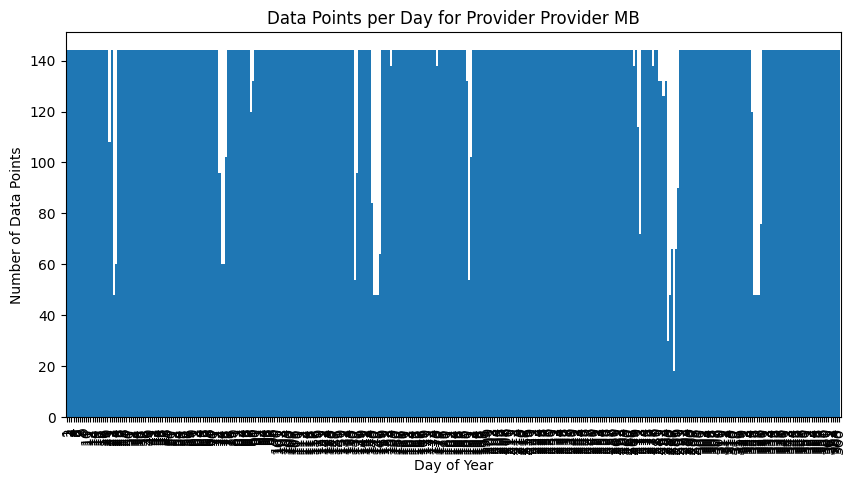

Variable Name: Vessel External Conditions Sea Water Temperature
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


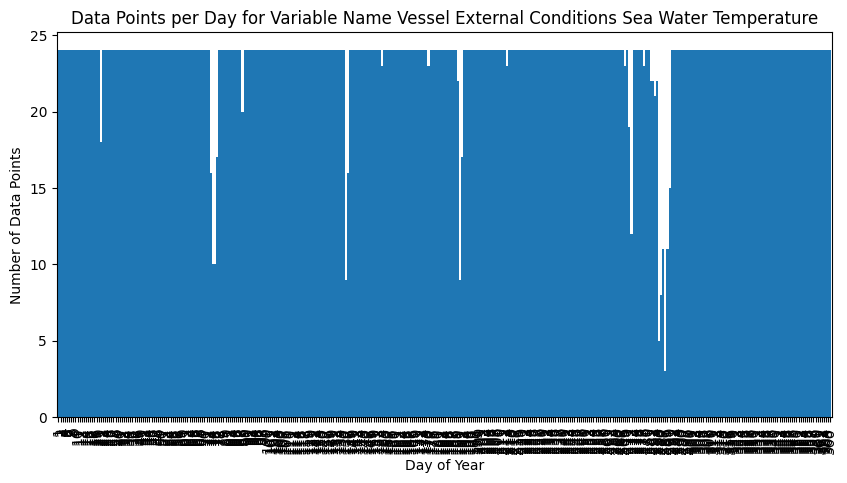

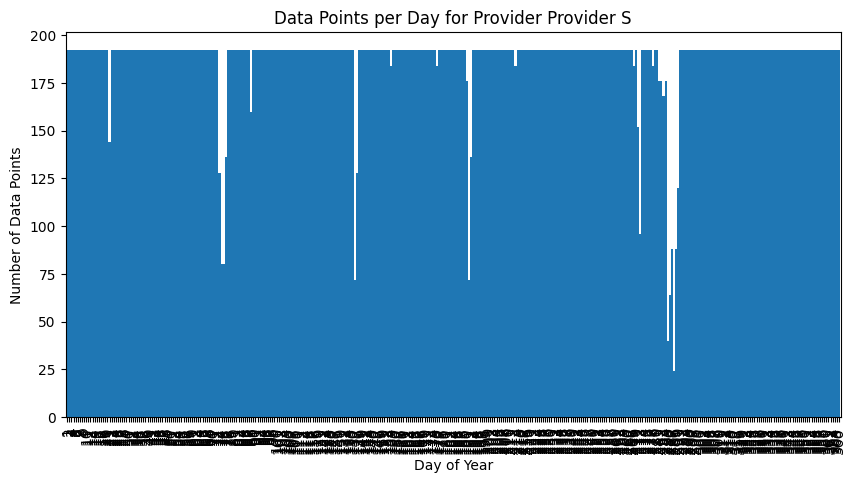

Variable Name: Vessel External Conditions Wind Relative Speed
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


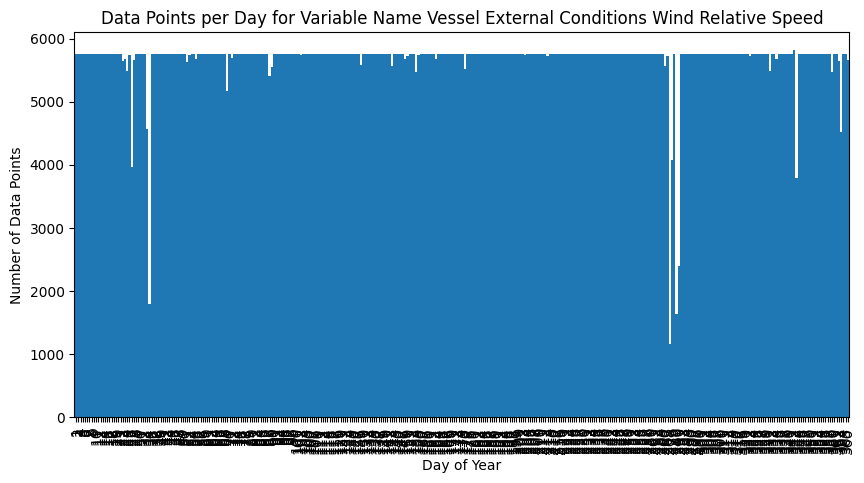

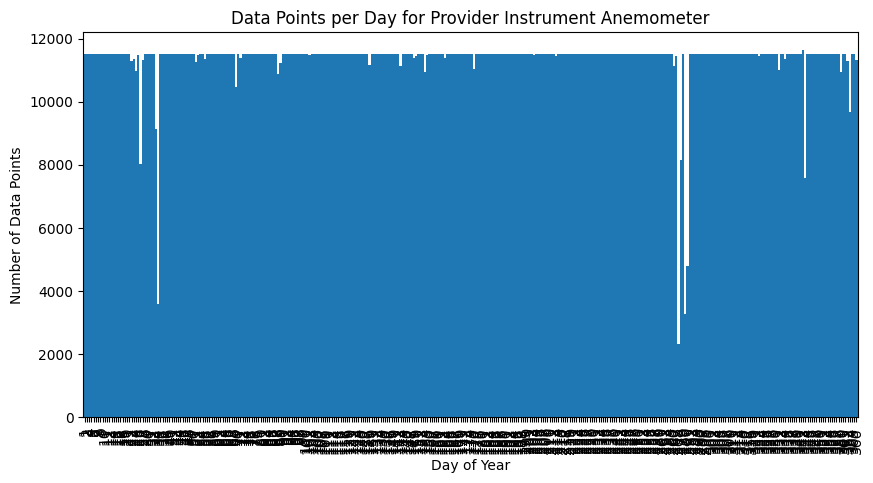

Variable Name: Vessel Hull Over Ground Speed
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


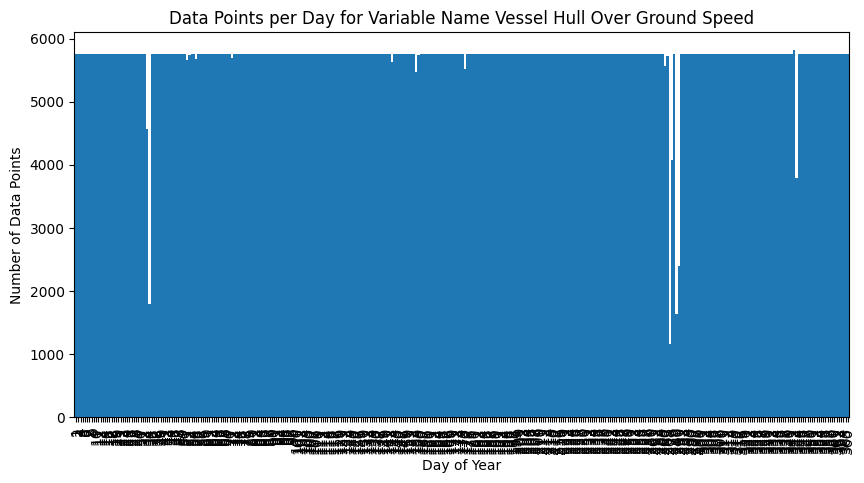

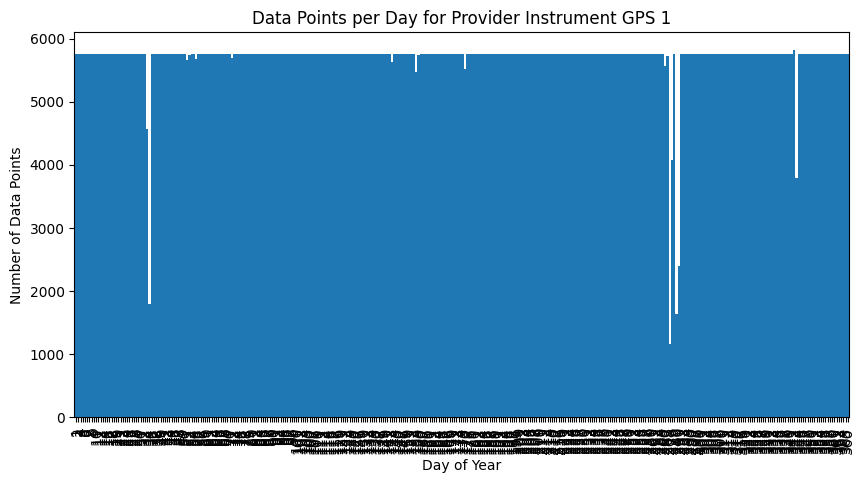

Variable Name: Vessel Hull Through Water Longitudinal Speed
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


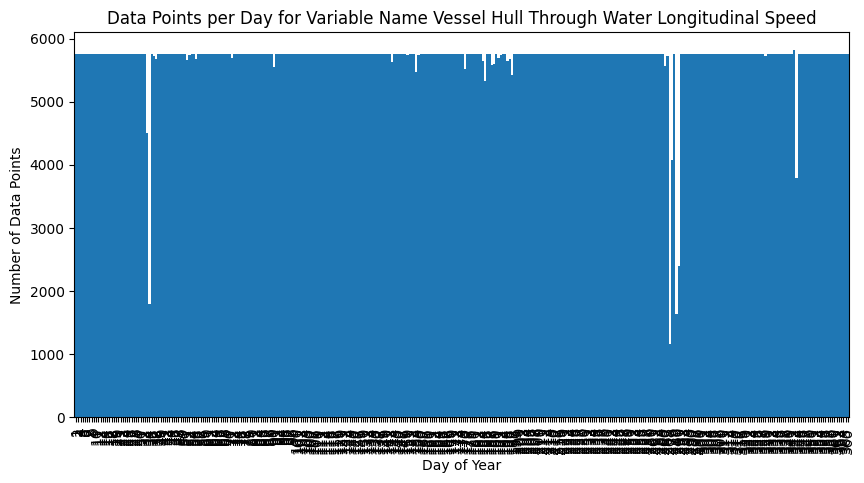

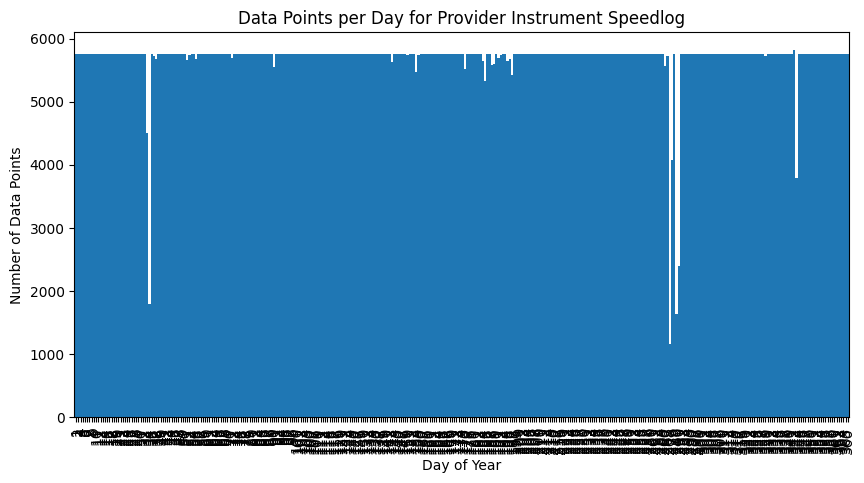

Variable Name: delta_fouling_penalty_index
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


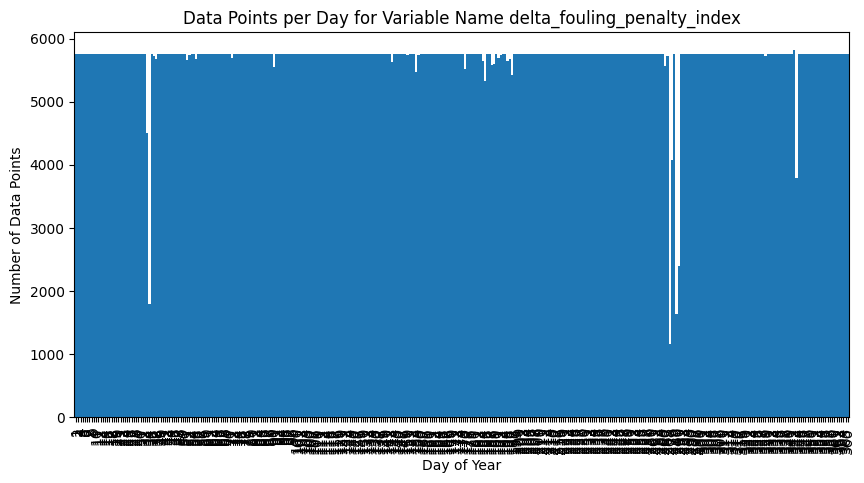

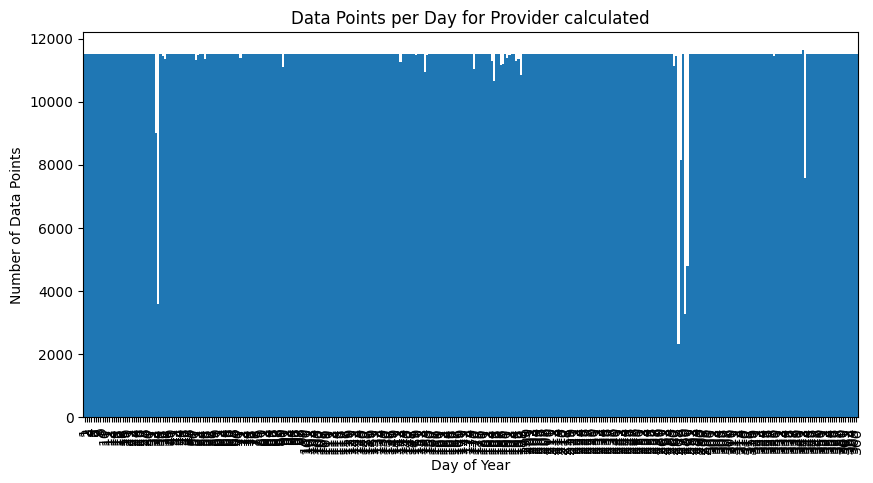

Variable Name: Vessel External Conditions Wind Relative Angle
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


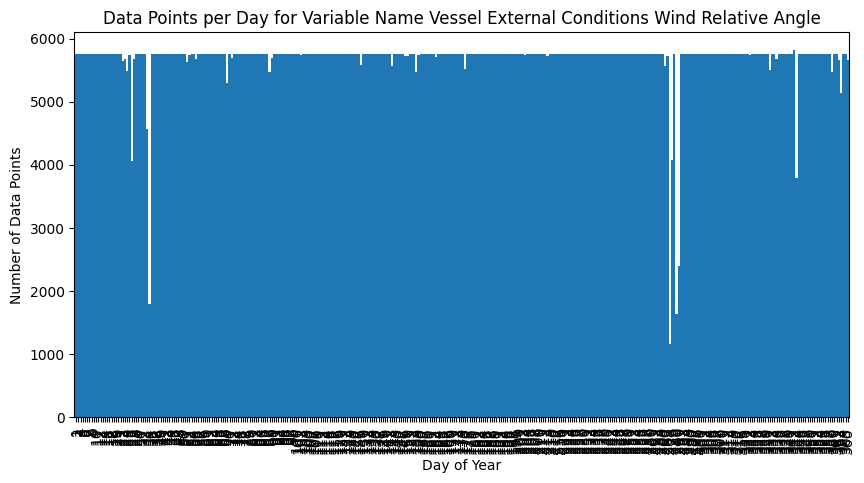

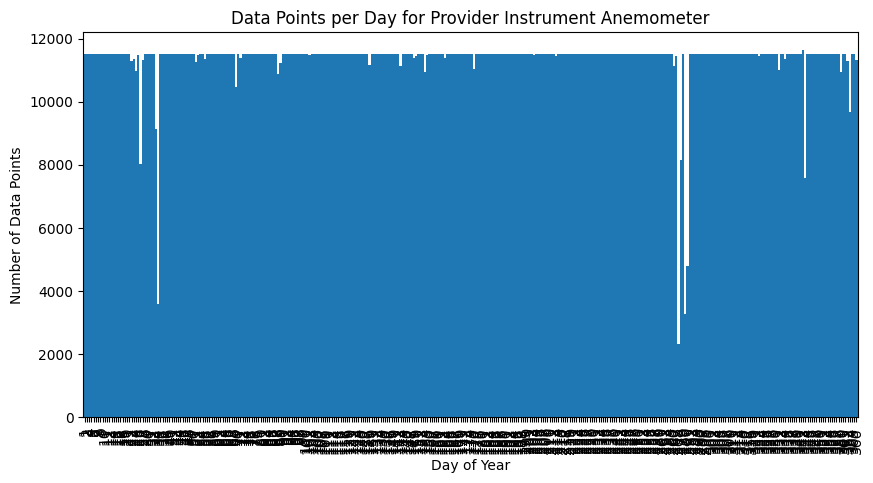

Variable Name: cumulative_fouling_penalty_index
Expected days: 365
Actual days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]


KeyboardInterrupt: 

In [33]:
for var_name, var_qid, source_name in qid_mappings_dict.itertuples(index=False):
    check_daily_distribution(df, var_qid, var_name)
    check_daily_source_distribution(df, source_name)

## Checking number of data points for each day of each month

In [ ]:
def check_monthly_distribution(df, month):
    month_data = df[df['utc_timestamp'].dt.month == month]
    counts = month_data['utc_timestamp'].dt.day.value_counts().sort_index()
    total_data_points = len(month_data)
    
    plt.figure(figsize=(10, 6))
    counts.plot(kind='bar')
    plt.title(f'Distribution of Data Points in {datetime(2023, month, 1).strftime("%B")} (Total: {total_data_points})')
    plt.xlabel('Day of Month')
    plt.ylabel('Number of Data Points')
    plt.show()

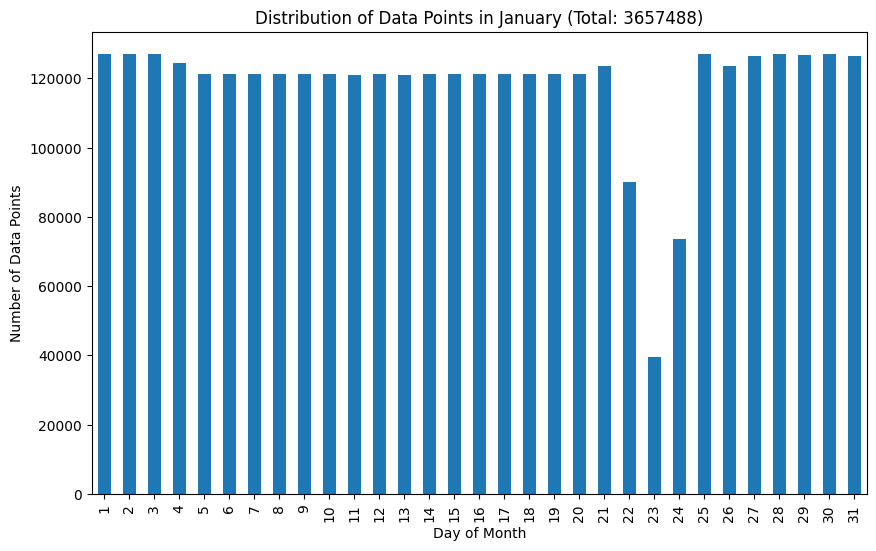

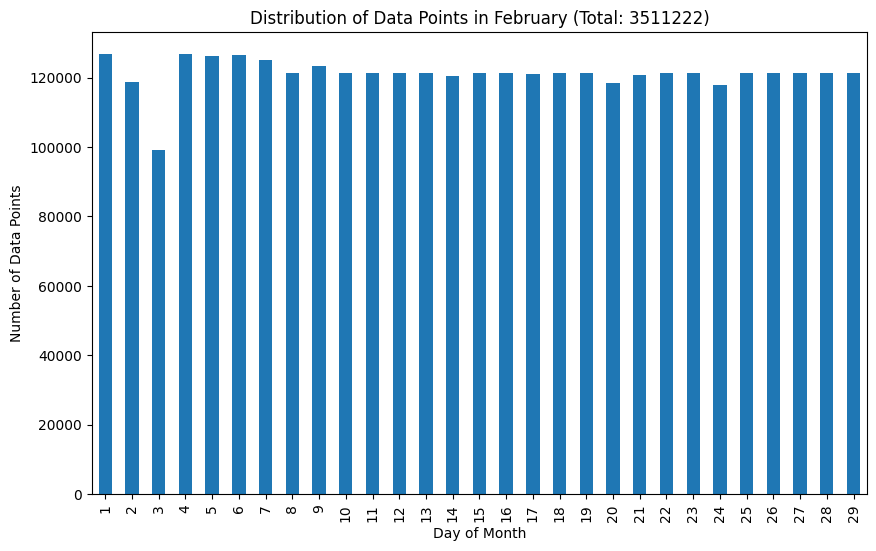

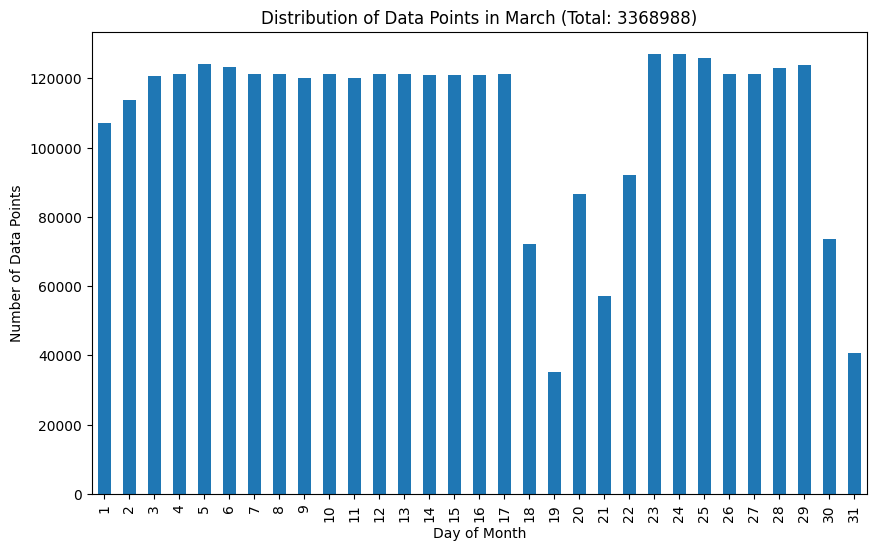

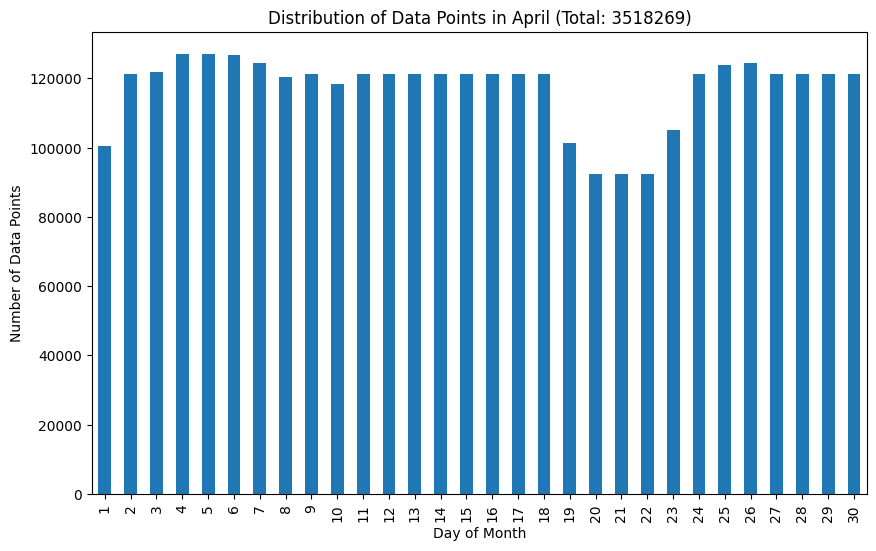

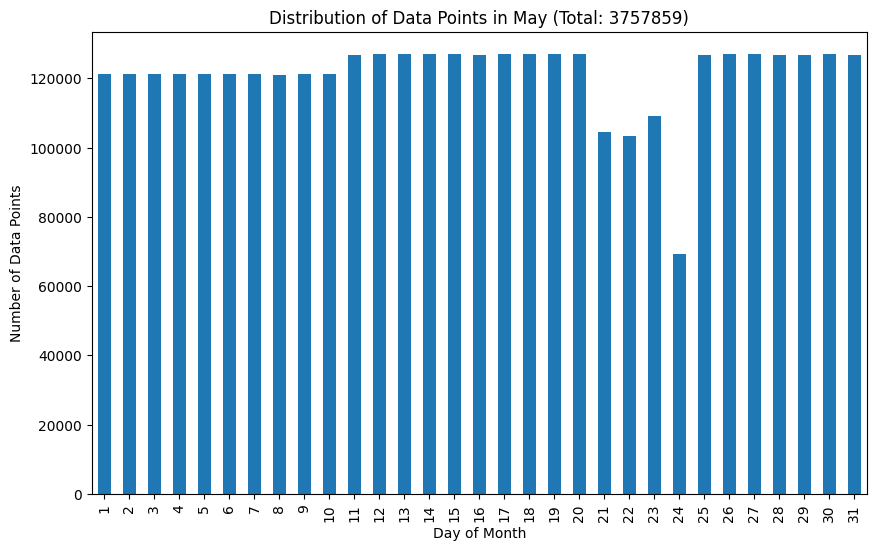

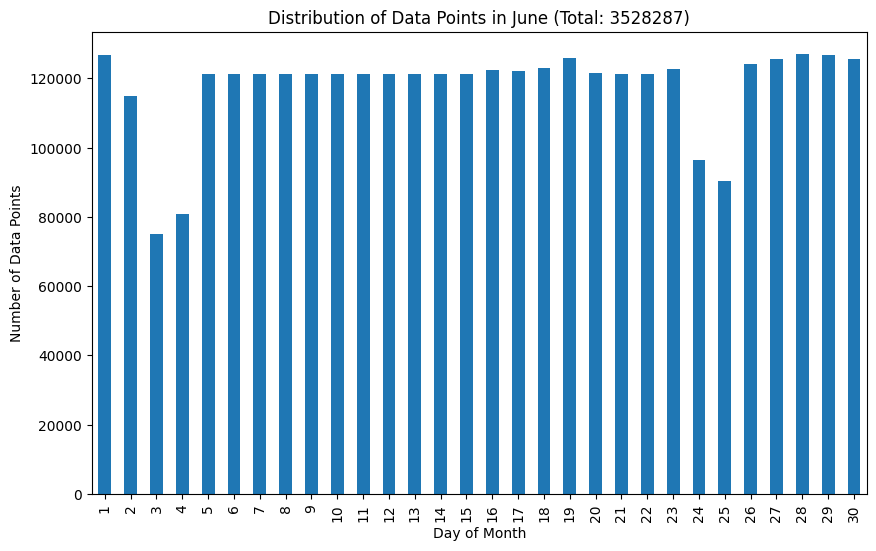

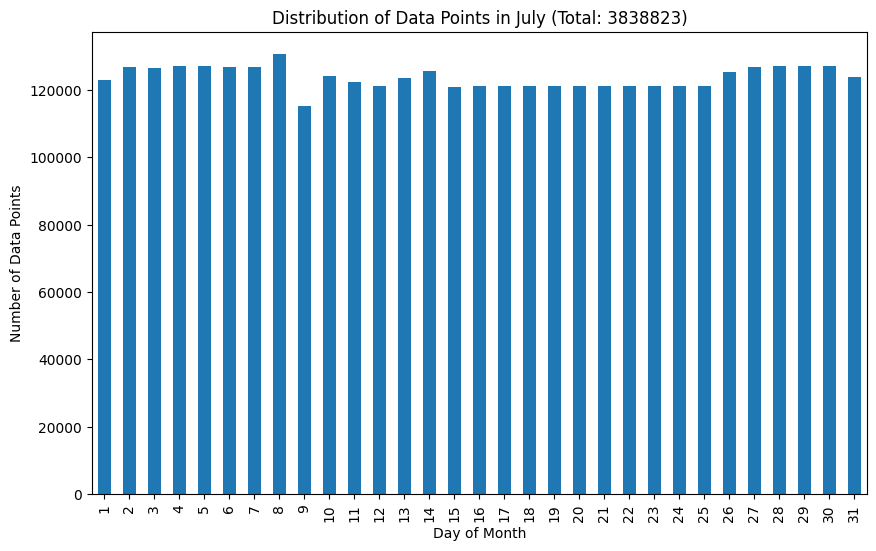

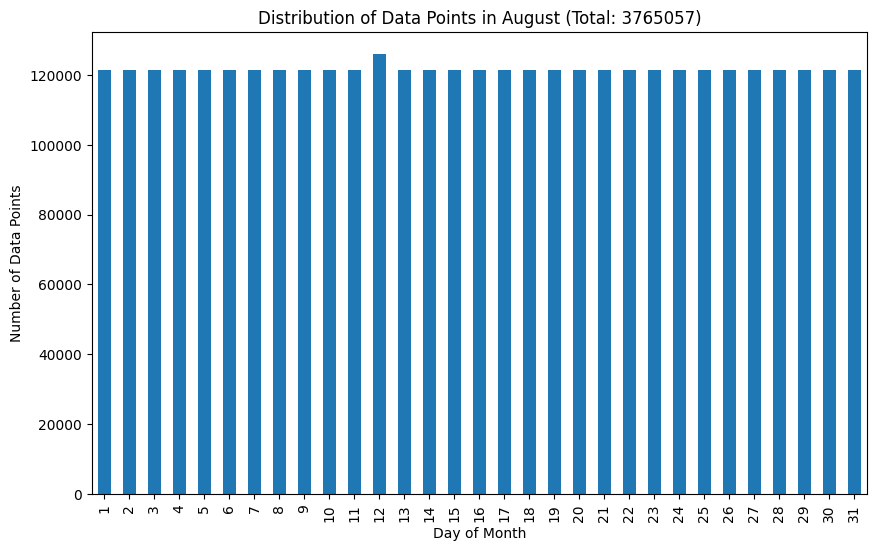

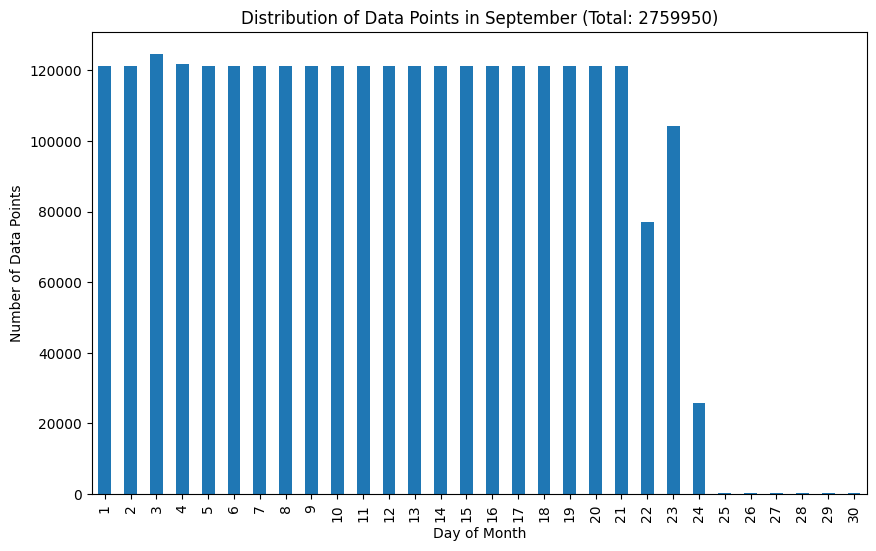

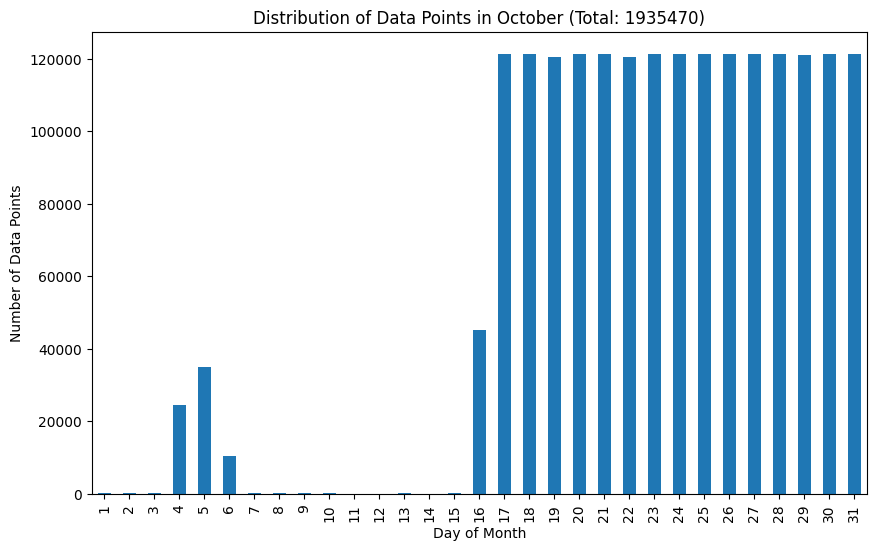

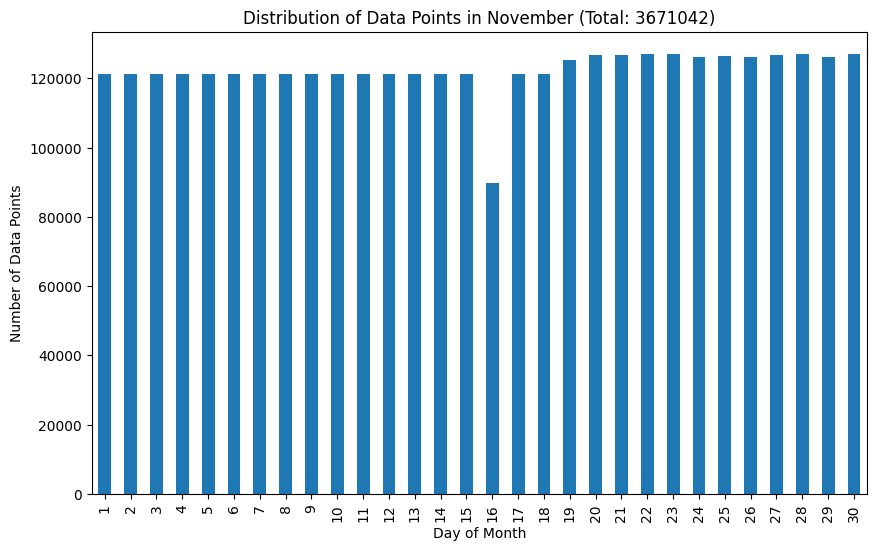

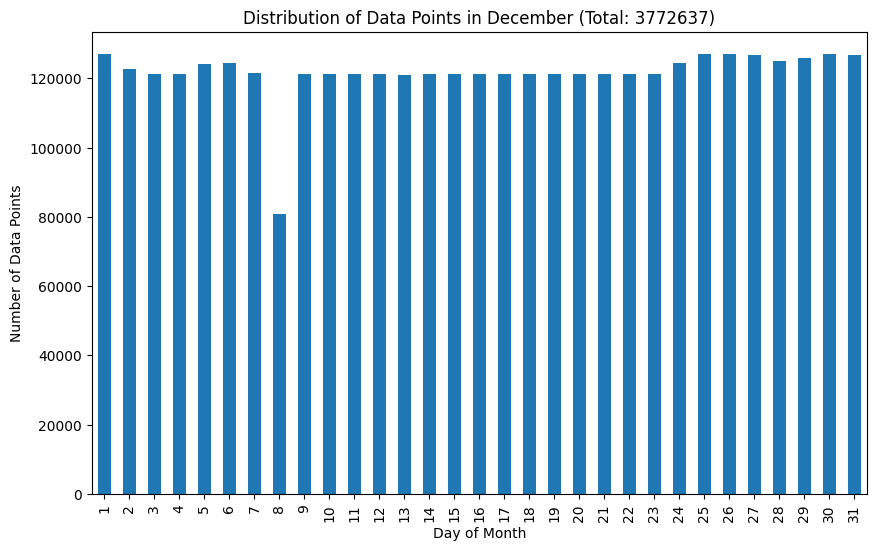

In [ ]:
for i in range(1, 13):
    check_monthly_distribution(df, i)

## Checking an example of each variable for correct datetime conversion

### (looks good)

In [ ]:
# set a random seed for reproducibility
np.random.seed(42)

In [ ]:
def inspect_datetime_conversion(df, qid_mappings_dict):
    for var_name, var_qid, source_name in qid_mappings_dict.itertuples(index=False):
        var_data = df[df['qid_mapping'] == var_qid]
        sampled_data = var_data.sample(n=5)
        sampled_data['month'] = sampled_data['utc_timestamp'].dt.month
        print(f"Variable Name: {var_name}")
        print(sampled_data[['utc_timestamp', 'value', 'month']])
        print("\n")

In [ ]:
inspect_datetime_conversion(df, qid_mappings_dict)

Variable Name: Vessel External Conditions Eastward Sea Water Velocity
                     utc_timestamp    value  month
19636623 2024-06-16 18:00:00+00:00  -0.2088      6
31715581 2024-10-04 13:00:00+00:00  -0.1283     10
32999916 2024-10-26 17:00:00+00:00  -0.1103     10
11537278 2024-04-09 06:00:00+00:00  -0.0395      4
3588871  2024-01-31 11:00:00+00:00   0.1137      1


Variable Name: Vessel External Conditions Northward Wind Velocity
                     utc_timestamp    value  month
38017305 2024-12-06 17:00:00+00:00  -1.2275     12
12883969 2024-04-20 17:00:00+00:00  -4.7975      4
16300518 2024-05-19 03:00:00+00:00   3.3088      5
4841724  2024-02-10 18:00:00+00:00   0.3981      2
37980220 2024-12-06 10:00:00+00:00   -4.204     12


Variable Name: Vessel External Conditions Northward Sea Water Velocity
                     utc_timestamp    value  month
31778595 2024-10-14 17:00:00+00:00  -0.0049     10
8363349  2024-03-11 00:00:00+00:00  -0.0662      3
29849385 2024-09-08 10:0

## Check distribution / histogram throughout the day for each variable

### (looks very uniform throughout the day)

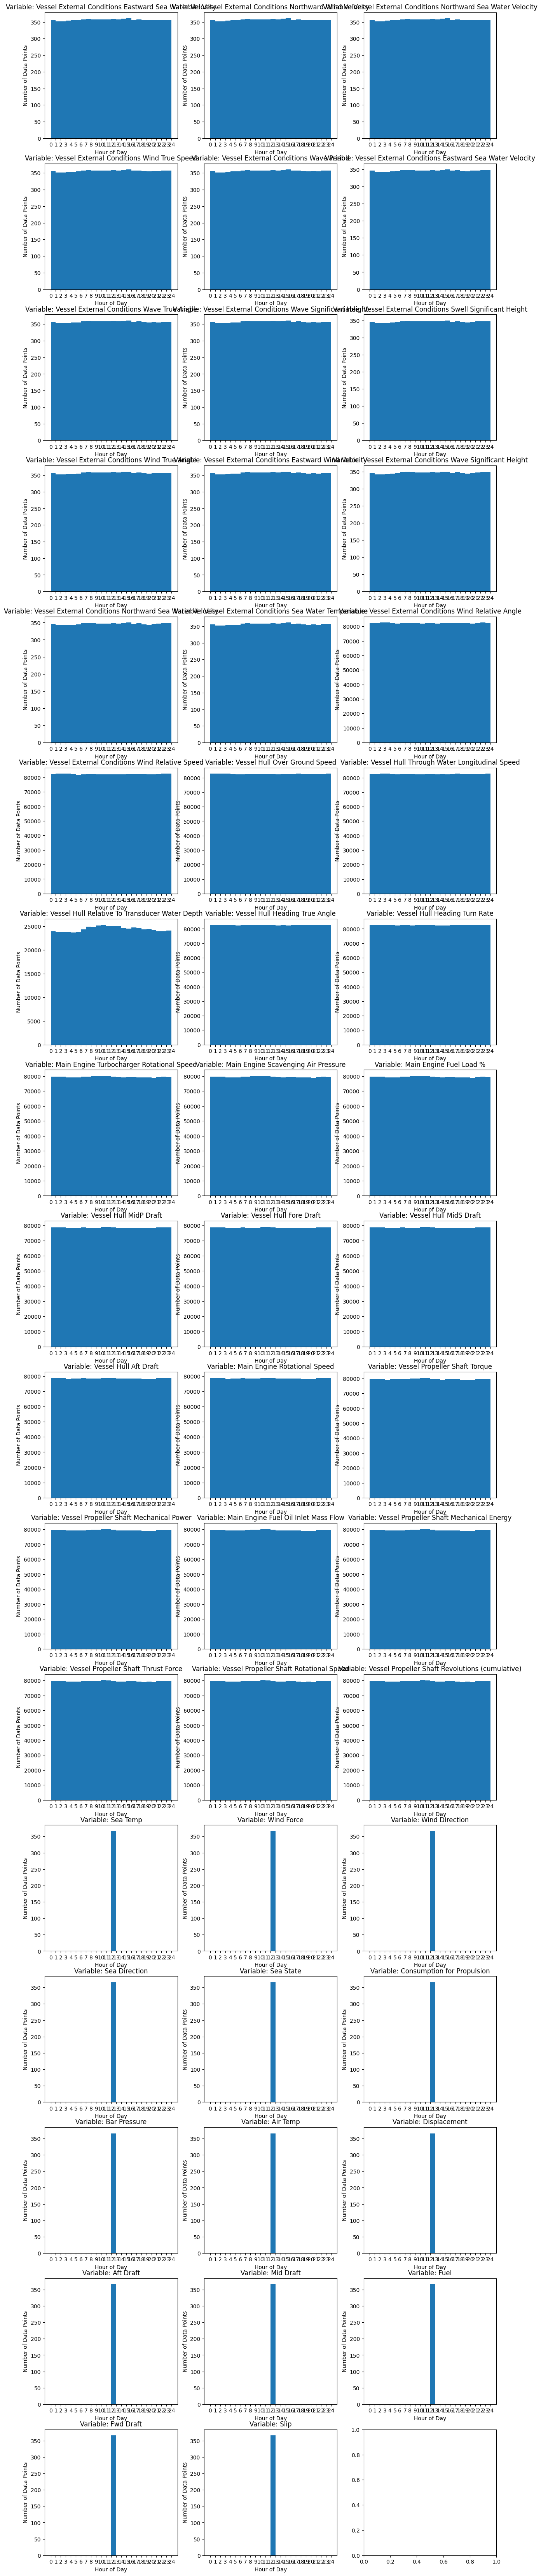

In [ ]:
# print the histograms in rows of 3 

fig, axes = plt.subplots(nrows=(len(qid_mappings_dict) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(qid_mappings_dict) + 2) // 3)))
axes = axes.flatten()

for i, (var_name, var_qid, source_name) in enumerate(qid_mappings_dict.itertuples(index=False)):
    var_data = df[df['qid_mapping'] == var_qid]
    var_data['hour'] = var_data['utc_timestamp'].dt.hour
    
    axes[i].hist(var_data['hour'], bins=24, range=(0, 24))
    axes[i].set_title(f'Variable: {var_name}')
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Number of Data Points')
    axes[i].set_xticks(range(0, 25))

## Derive when cleaning events happened by looking at speed

### (not really possible since there are multiple full stops)

In [60]:
def variable_line_graph(df, qid_mapping, var_name, month,
                        voyage_qid="5::0::0::0_0::0::0::0::0_0::0::0::0_6"):
    # Filter for the specific month and sensor
    month_data = df[(df['utc_timestamp'].dt.month == month) & (df['qid_mapping'] == qid_mapping)].copy()
    
    # Convert value column to numeric
    month_data['value'] = pd.to_numeric(month_data['value'], errors='coerce')
    
    # Set timestamp as index and resample to hourly mean
    month_data = month_data.set_index('utc_timestamp')
    hourly_data = month_data['value'].resample('h').mean()
    
    # Get voyage data for the same month
    voyage_data = df[(df['utc_timestamp'].dt.month == month) & (df['qid_mapping'] == voyage_qid)].copy()
    voyage_data['value'] = pd.to_numeric(voyage_data['value'], errors='coerce')
    voyage_data = voyage_data.dropna(subset=['value']).sort_values('utc_timestamp')
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hourly_data.index, hourly_data.values, color='C0', zorder=2)
    
    # Shade voyage periods and label with voyage ID
    if not voyage_data.empty:
        for vid, grp in voyage_data.groupby('value'):
            t_start = grp['utc_timestamp'].min()
            t_end = grp['utc_timestamp'].max()
            ax.axvspan(t_start, t_end, alpha=0.15, color='green', zorder=1)
            mid = t_start + (t_end - t_start) / 2
            ax.text(mid, ax.get_ylim()[1], f'V{int(vid)}',
                    ha='center', va='bottom', fontsize=7, color='green', alpha=0.8)
    
    ax.set_title(f'{var_name} in {datetime(2023, month, 1).strftime("%B")}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=10))
    fig.tight_layout()
    
    plt.show()


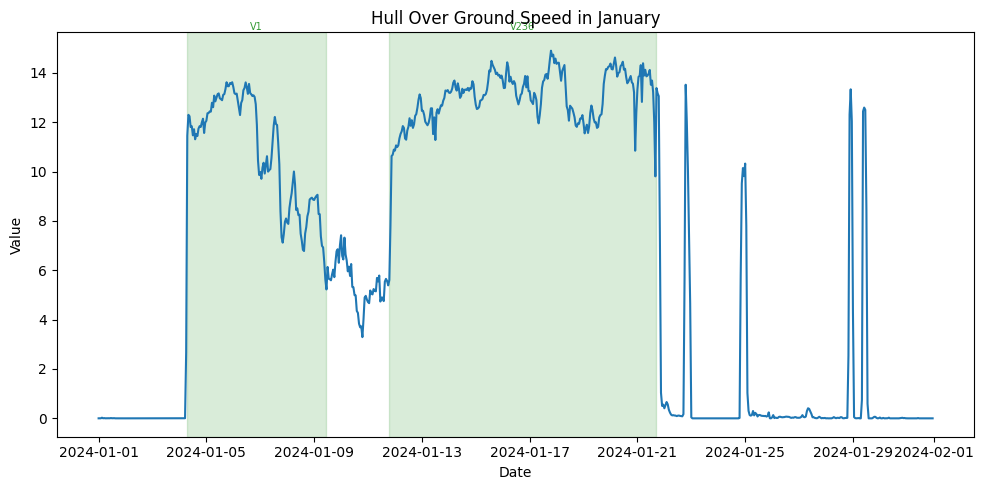

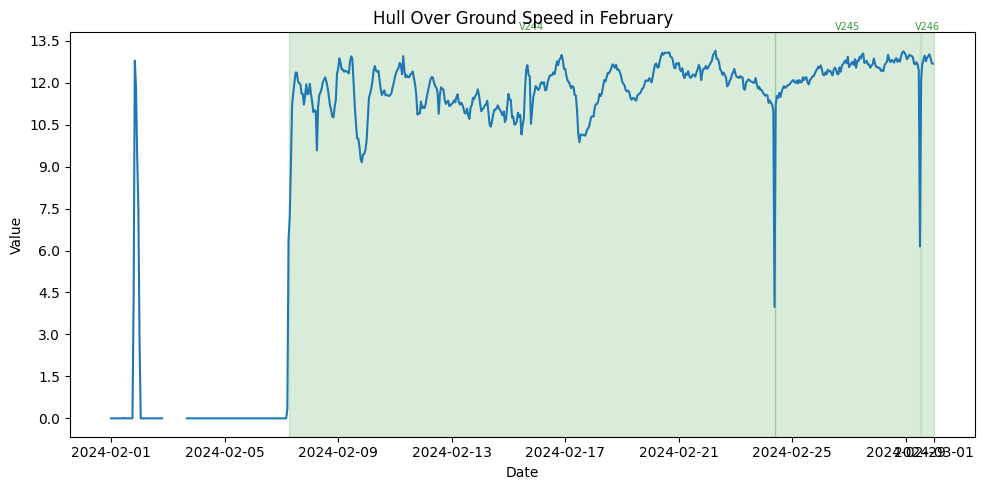

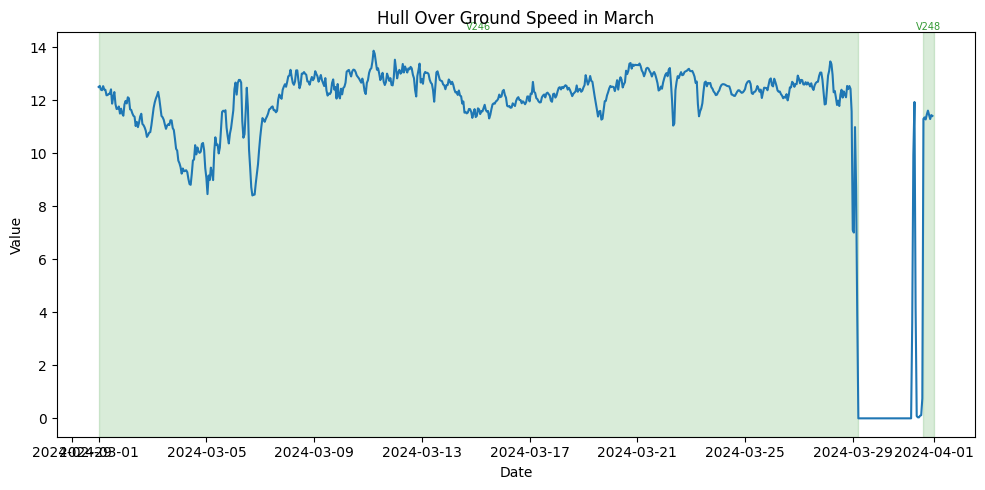

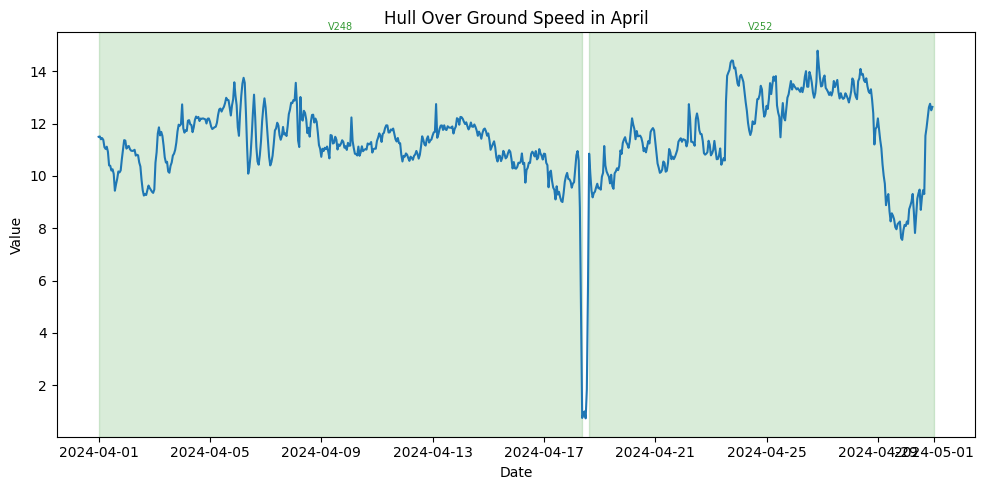

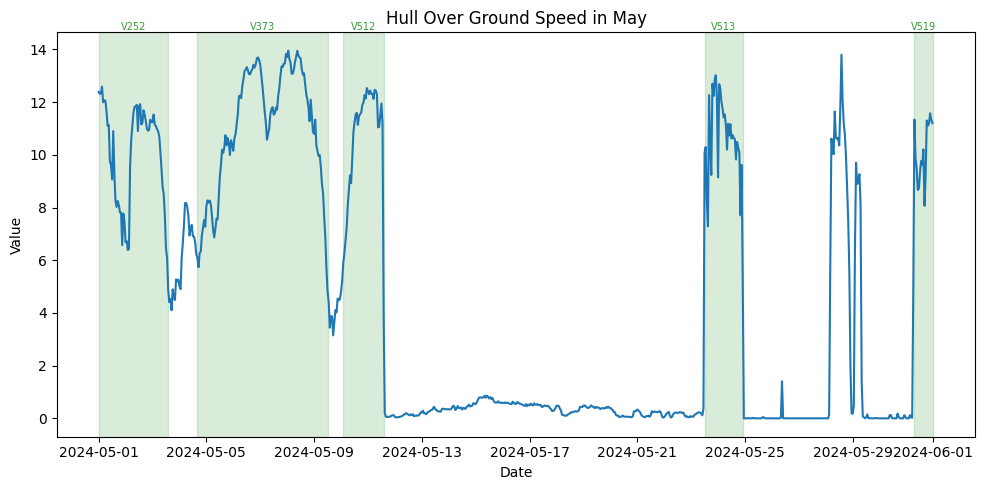

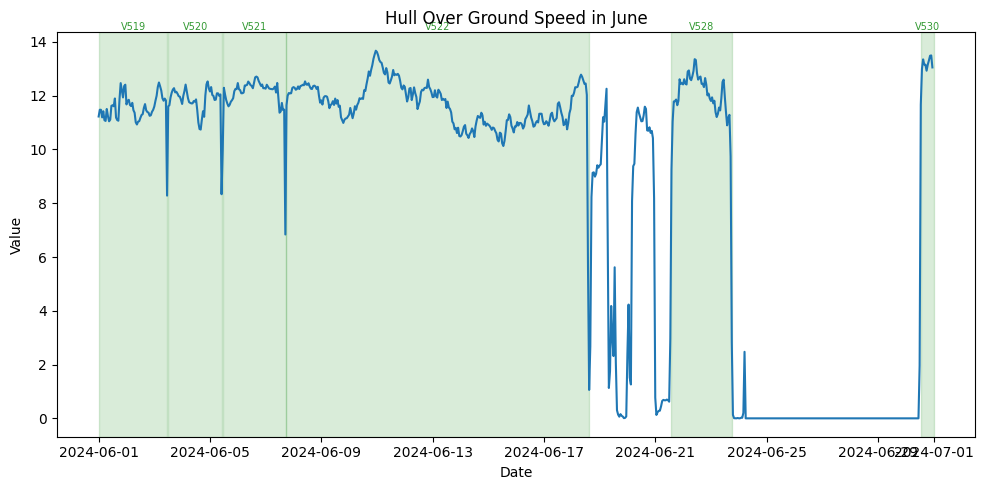

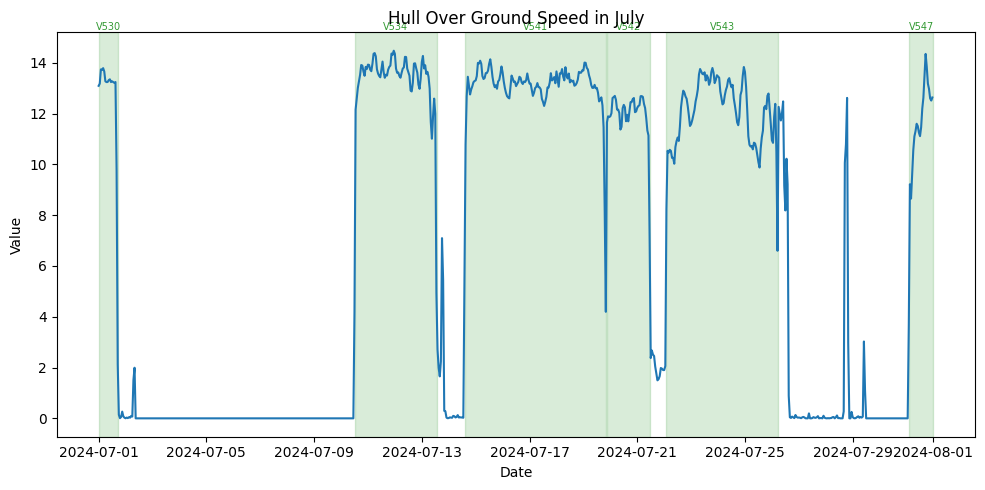

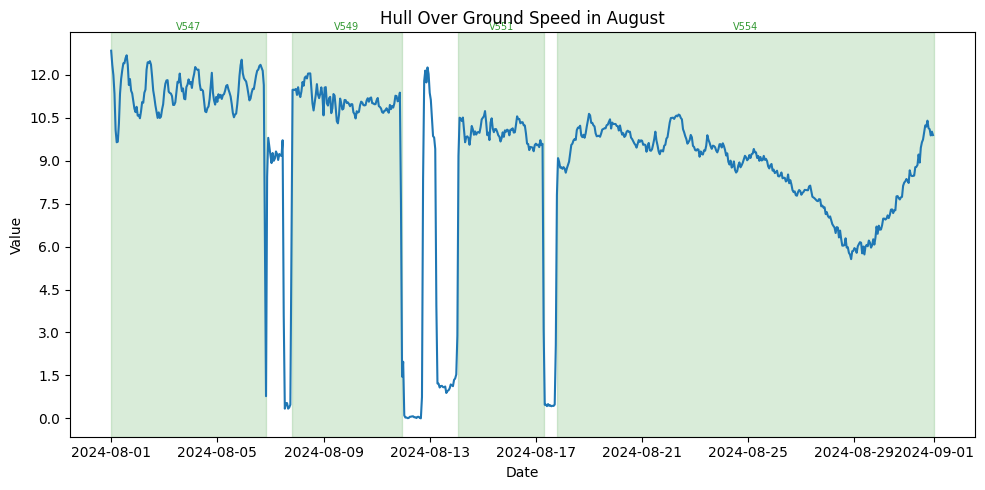

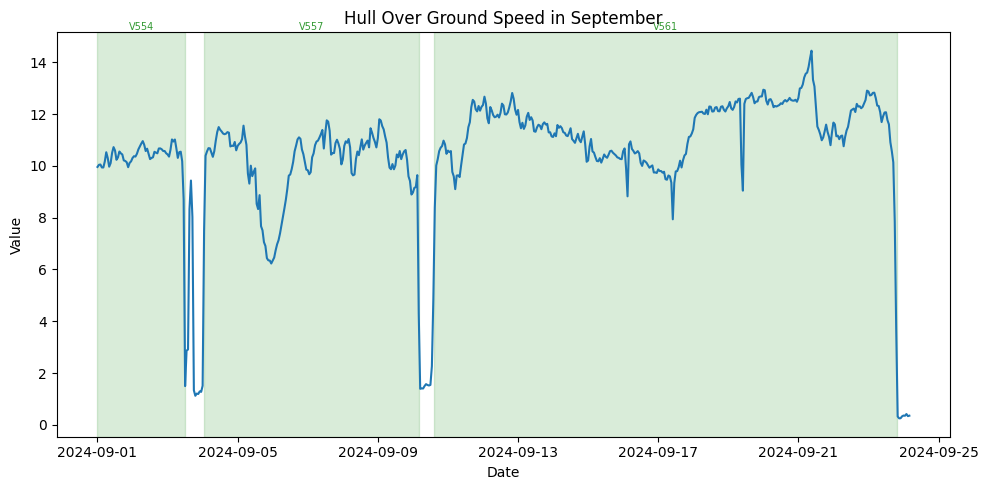

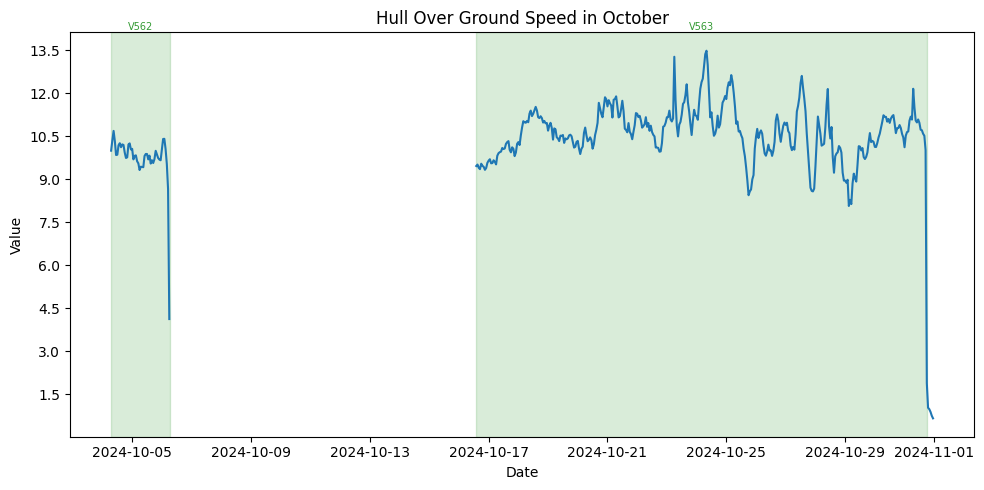

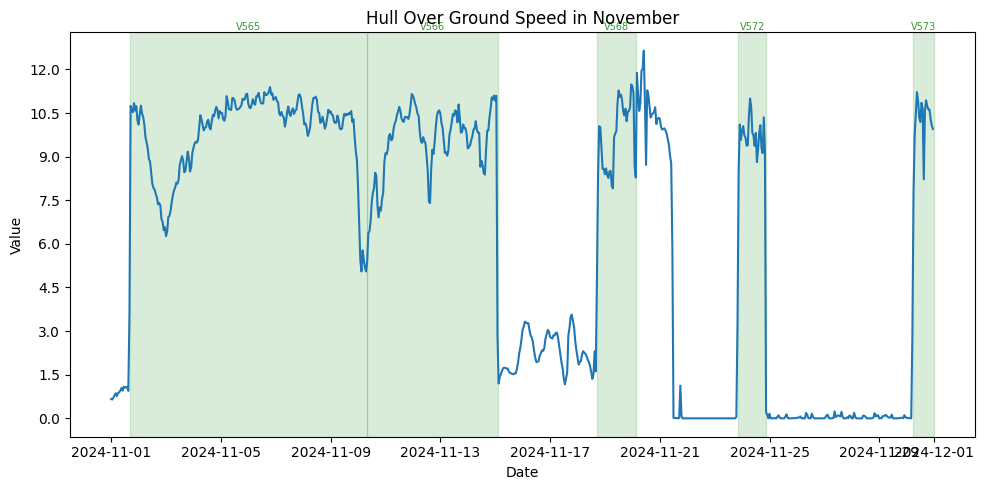

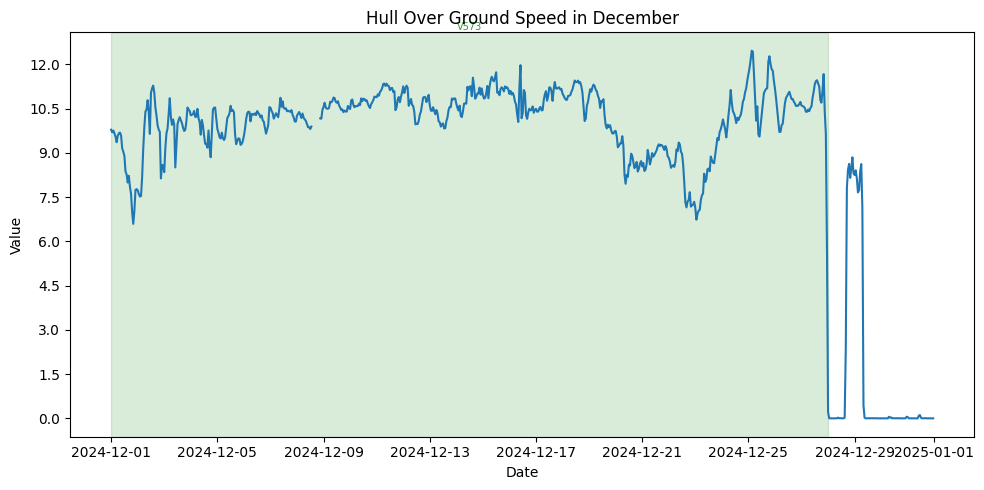

In [61]:
for i in range(1, 13):
    variable_line_graph(df,'2::0::6::1_1::1::0::2::0_1::0::1::0_8', 'Hull Over Ground Speed', i)

## Inspect differences in timing

In [ ]:
def inspect_timing(df, qid_mappings_dict, start_time, end_time, interval_seconds=15):
    """ creates a scatterplot where the x axis is the time of measurement and the y axis is the name of the variable"""
    import pandas as pd
    
    plt.figure(figsize=(15, 7))
    
    # Plot the data points
    for var_name, var_qid, source_name in qid_mappings_dict.itertuples(index=False):
        var_data = df[(df['qid_mapping'] == var_qid) & 
                      (df['utc_timestamp'] >= start_time) & 
                      (df['utc_timestamp'] <= end_time)]
        plt.scatter(var_data['utc_timestamp'], [var_name]*len(var_data), alpha=0.5)
    
    # Add vertical lines at regular intervals
    time_marks = pd.date_range(start=start_time, end=end_time, freq=f'{interval_seconds}s')
    plt.vlines(time_marks, ymin=plt.ylim()[0], ymax=plt.ylim()[1], 
               colors='gray', alpha=0.3, linestyles='--', linewidths=0.5)
    
    plt.xlabel('Time of Measurement')
    plt.ylabel('Variable Name')
    plt.title('Timing of Measurements for Different Variables')
    plt.tight_layout()
    plt.show()

In [ ]:
# Create 5 dataframe samples at different random times
samples = []
for i in range(5):
    # Choose a random value for start_time in 2024 and set end_time to be 1 minute later
    sample_start_time = pd.Timestamp(2024, random.randint(1, 12), random.randint(1, 28), random.randint(0, 23), random.randint(0, 57), 0, 0, tz='UTC')
    sample_end_time = sample_start_time + timedelta(minutes=1)
    
    # Make a segment of the dataframe for the time window
    df_sample = df[(df['utc_timestamp'] >= sample_start_time) & (df['utc_timestamp'] <= sample_end_time)]
    samples.append((df_sample, sample_start_time, sample_end_time))
    
    print(f"Sample {i+1}: {sample_start_time} to {sample_end_time}, {len(df_sample)} rows")




Sample 1: 2024-01-28 16:04:00+00:00 to 2024-01-28 16:05:00+00:00, 88 rows
Sample 2: 2024-08-13 16:57:00+00:00 to 2024-08-13 16:58:00+00:00, 84 rows
Sample 3: 2024-07-18 00:16:00+00:00 to 2024-07-18 00:17:00+00:00, 84 rows
Sample 4: 2024-04-23 03:48:00+00:00 to 2024-04-23 03:49:00+00:00, 64 rows
Sample 5: 2024-01-05 19:48:00+00:00 to 2024-01-05 19:49:00+00:00, 84 rows


In [ ]:
for sample_df, start_time, end_time in samples:
    inspect_timing(sample_df, sensor_only_qid_dict, start_time, end_time)

#### Testing the hypothesis that all datapoints are either spaced very close to the intended interval or very far away (turned of/malfunctioning sensor)

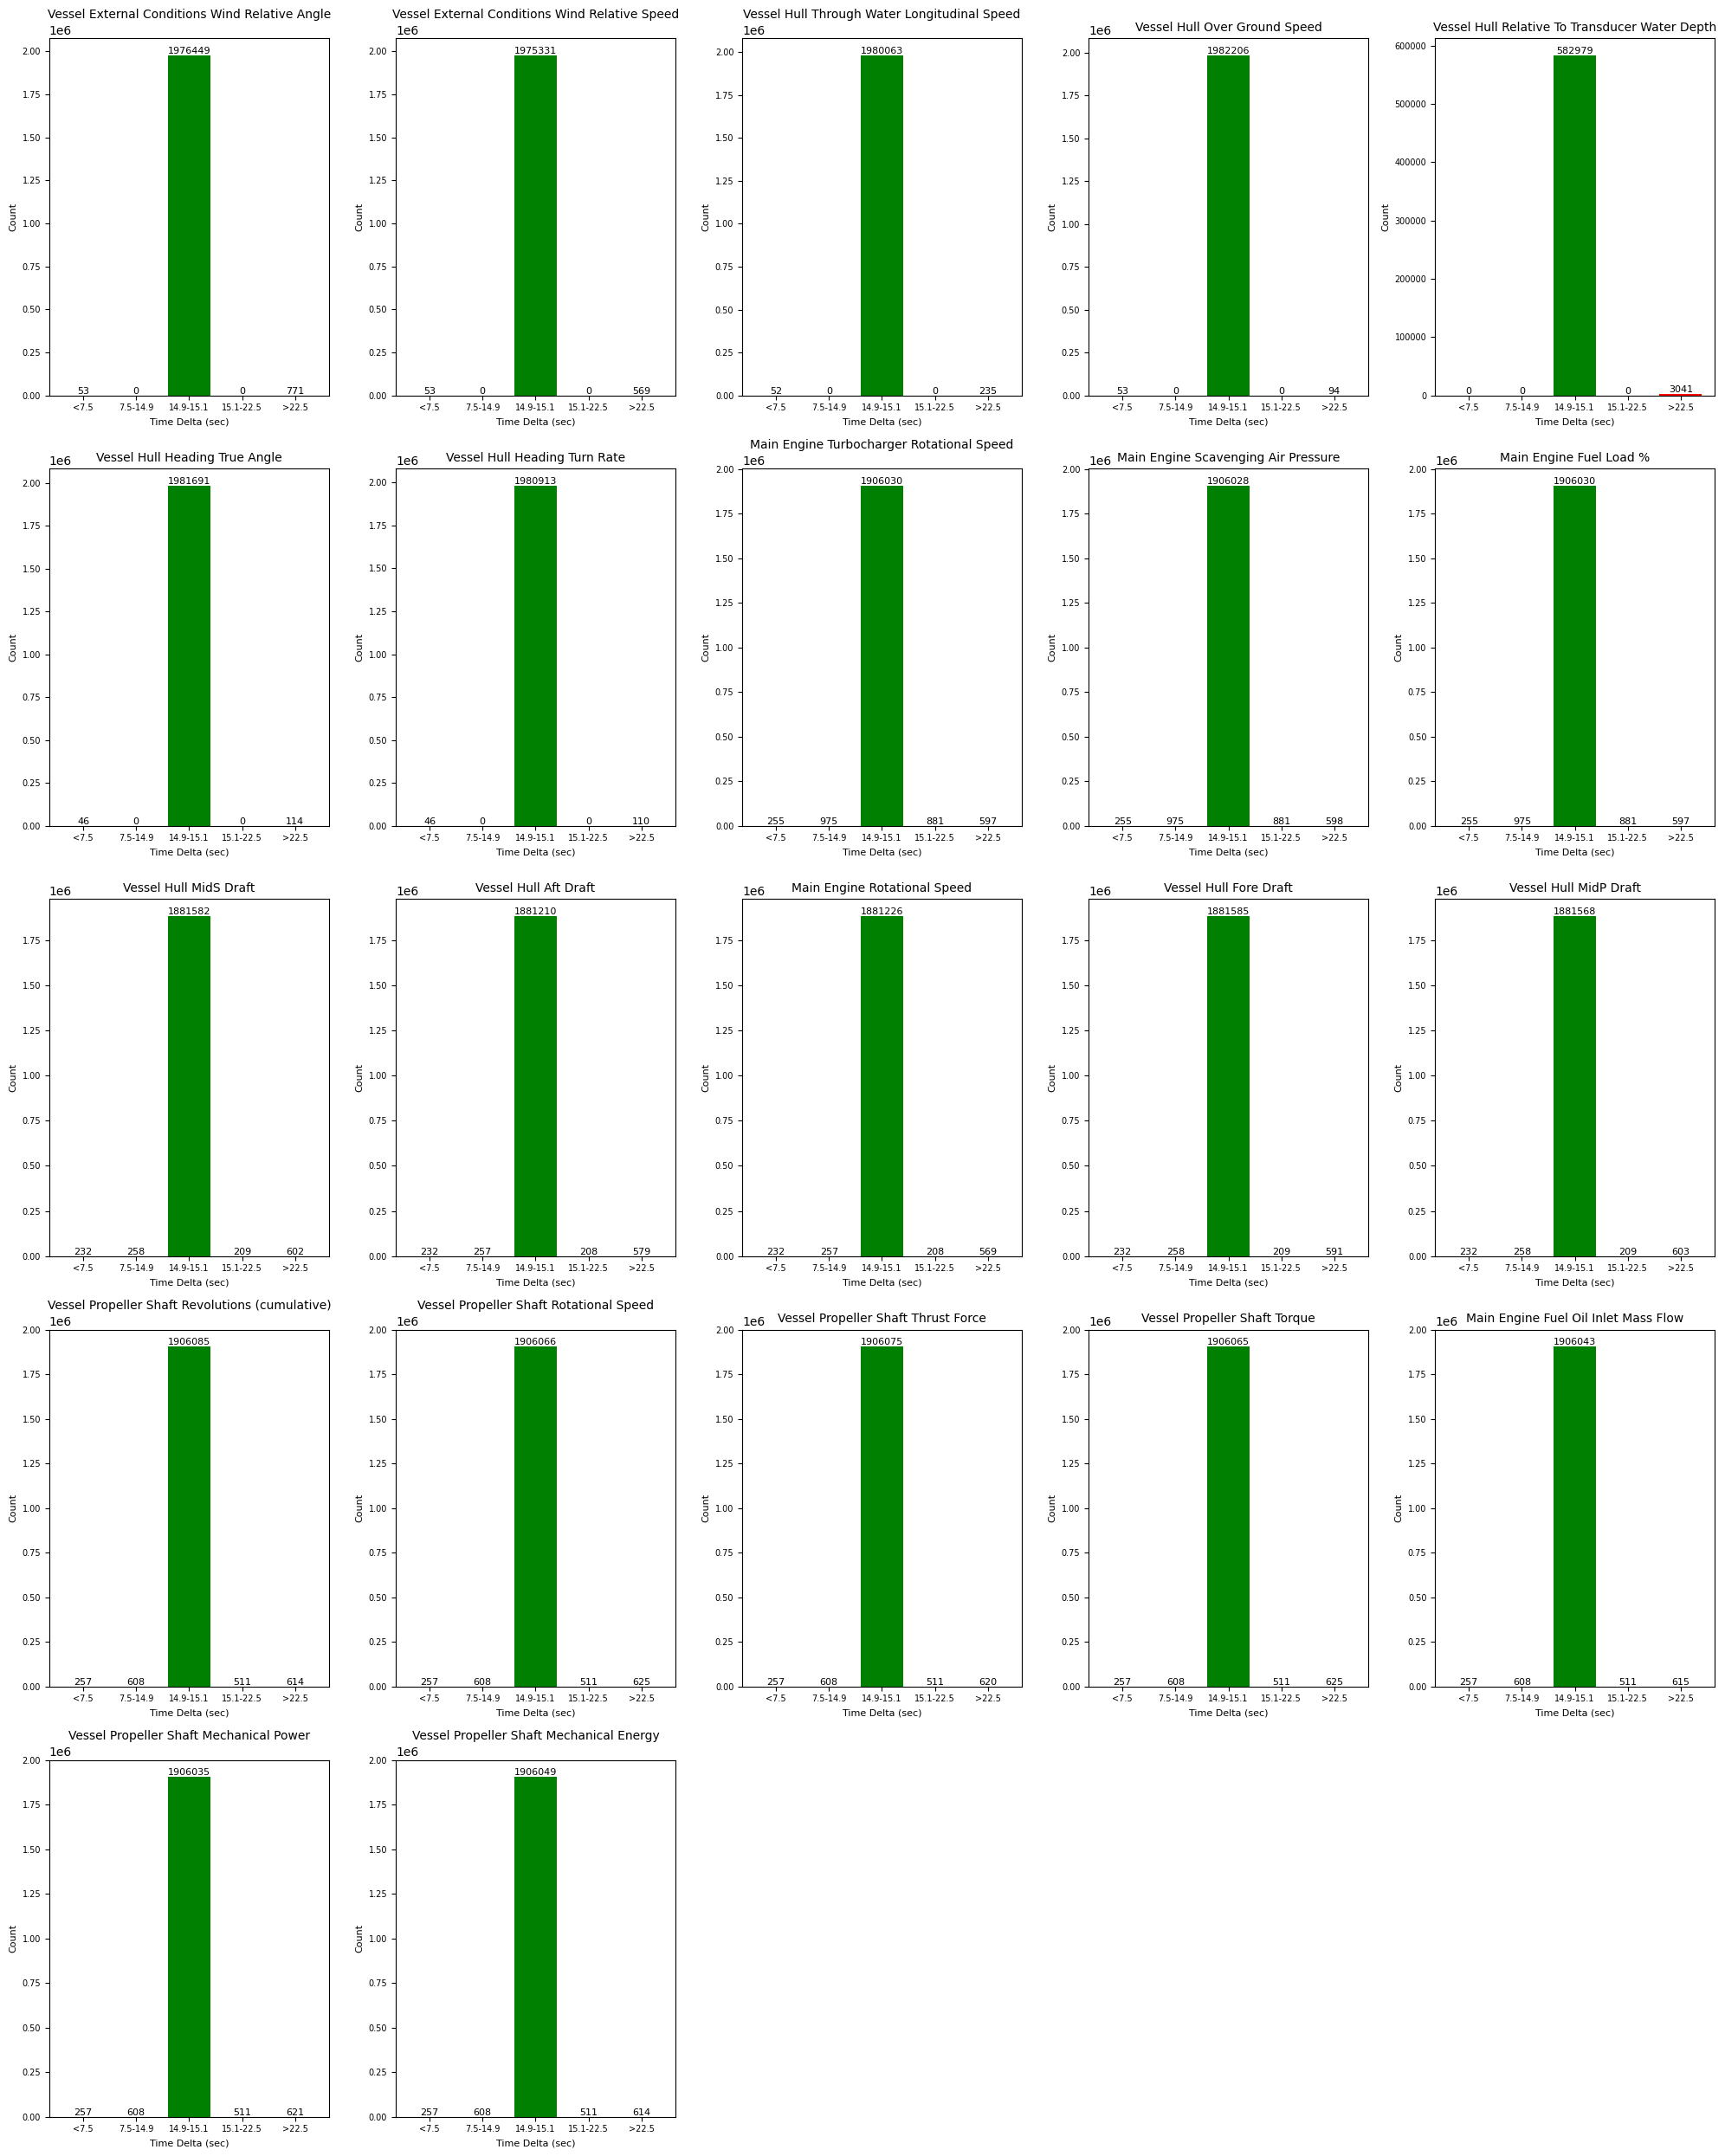

                                      quantity_name  <7.5 sec  \
0    Vessel External Conditions Wind Relative Angle        53   
1    Vessel External Conditions Wind Relative Speed        53   
2      Vessel Hull Through Water Longitudinal Speed        52   
3                     Vessel Hull Over Ground Speed        53   
4    Vessel Hull Relative To Transducer Water Depth         0   
5                    Vessel Hull Heading True Angle        46   
6                     Vessel Hull Heading Turn Rate        46   
7         Main Engine Turbocharger Rotational Speed       255   
8               Main Engine Scavenging Air Pressure       255   
9                           Main Engine Fuel Load %       255   
10                           Vessel Hull MidS Draft       232   
11                            Vessel Hull Aft Draft       232   
12                     Main Engine Rotational Speed       232   
13                           Vessel Hull Fore Draft       232   
14                       

In [ ]:
# Calculate number of variables and grid dimensions
n_vars = len(sensor_only_qid_dict)
n_cols = 5
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Create subplot grid
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Collect results in a list
timing_results = []
plot_idx = 0

for var_name, var_qid, source_name in sensor_only_qid_dict.itertuples(index=False):
    var_data = grouped.get_group(var_qid)
    
    # Extract time_delta_sec and drop NaN (first value)
    time_delta = var_data['time_delta_sec'].dropna()
    
    # Count using boolean operations (single pass, much faster)
    less_than_7_5 = (time_delta < 7.5).sum()
    between_7_5_and_14_9 = ((time_delta >= 7.5) & (time_delta <= 14.9)).sum()
    between_14_9_and_15_1 = ((time_delta > 14.9) & (time_delta < 15.1)).sum()
    between_15_1_and_22_5 = ((time_delta >= 15.1) & (time_delta <= 22.5)).sum()
    greater_than_22_5 = (time_delta > 22.5).sum()
    
    total_counts = less_than_7_5 + between_7_5_and_14_9 + between_14_9_and_15_1 + between_15_1_and_22_5 + greater_than_22_5
    
    # Verify all rows were counted
    if total_counts != len(time_delta):
        logger.error(f"Timing bucket counts ({total_counts}) do not sum up to total observations ({len(time_delta)}) for variable {var_name}. Skipping.")
    else:
        # Append to list
        timing_results.append({
            'quantity_name': var_name,
            '<7.5 sec': less_than_7_5,
            '7.5<= and <=14.9 sec': between_7_5_and_14_9,
            '14.9< and <15.1 sec': between_14_9_and_15_1,
            '15.1<= and <=22.5 sec': between_15_1_and_22_5,
            '>22.5 sec': greater_than_22_5
        })
        
        # Bar plot on grid
        ax = axes[plot_idx]
        bars = ax.bar(['<7.5', '7.5-14.9', '14.9-15.1', '15.1-22.5', '>22.5'], 
                     [less_than_7_5, between_7_5_and_14_9, between_14_9_and_15_1, between_15_1_and_22_5, greater_than_22_5], 
                     color=['red','yellow', 'green', 'yellow', 'red'])
        
        # Add value counts on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=8)
        
        ax.set_title(f'{var_name}', fontsize=10)
        ax.set_xlabel('Time Delta (sec)', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Create DataFrame once at the end
timing_buckets = pd.DataFrame(timing_results)
print(timing_buckets)

#### Testing for weather data as well

#### ...

In [ ]:
# Calculate number of variables and grid dimensions for weather data
n_vars_weather = len(weather_only_qid_dict)
n_cols_weather = 5
n_rows_weather = (n_vars_weather + n_cols_weather - 1) // n_cols_weather  # Ceiling division

# Create subplot grid
fig, axes = plt.subplots(nrows=n_rows_weather, ncols=n_cols_weather, figsize=(20, 5 * n_rows_weather))
axes = axes.flatten() if n_rows_weather > 1 else [axes] if n_cols_weather == 1 else axes

# Collect results in a list
timing_results_weather = []
plot_idx = 0

for var_name, var_qid, source_name in weather_only_qid_dict.itertuples(index=False):
    var_data = grouped.get_group(var_qid)
    
    # Extract time_delta_sec and drop NaN
    time_delta = var_data['time_delta_sec'].dropna()
    
    # Get intended interval for this variable (default to 3600 for weather if not found)
    intended_interval = INTENDED_SAMPLING_INTERVALS_SECONDS.get(var_name, 3600)
    
    # Define buckets based on intended interval
    # Using similar proportions as sensor data: 0.5x, 0.5x-0.993x, 0.993x-1.007x, 1.007x-1.5x, >1.5x
    bucket_1_max = intended_interval * 0.5
    bucket_2_max = intended_interval * 0.993
    bucket_3_max = intended_interval * 1.007
    bucket_4_max = intended_interval * 1.5
    
    # Count using boolean operations
    less_than_half = (time_delta < bucket_1_max).sum()
    between_half_and_lower = ((time_delta >= bucket_1_max) & (time_delta <= bucket_2_max)).sum()
    within_tolerance = ((time_delta > bucket_2_max) & (time_delta < bucket_3_max)).sum()
    between_upper_and_1_5x = ((time_delta >= bucket_3_max) & (time_delta <= bucket_4_max)).sum()
    greater_than_1_5x = (time_delta > bucket_4_max).sum()
    
    total_counts = less_than_half + between_half_and_lower + within_tolerance + between_upper_and_1_5x + greater_than_1_5x
    
    # Verify all rows were counted
    if total_counts != len(time_delta):
        logger.error(f"Timing bucket counts ({total_counts}) do not sum up to total observations ({len(time_delta)}) for variable {var_name}. Skipping.")
    else:
        # Append to list
        timing_results_weather.append({
            'quantity_name': var_name,
            f'<{bucket_1_max:.1f}s': less_than_half,
            f'{bucket_1_max:.1f}-{bucket_2_max:.1f}s': between_half_and_lower,
            f'{bucket_2_max:.1f}-{bucket_3_max:.1f}s': within_tolerance,
            f'{bucket_3_max:.1f}-{bucket_4_max:.1f}s': between_upper_and_1_5x,
            f'>{bucket_4_max:.1f}s': greater_than_1_5x
        })
        
        # Bar plot on grid
        ax = axes[plot_idx]
        bars = ax.bar([f'<{bucket_1_max:.0f}', f'{bucket_1_max:.0f}-{bucket_2_max:.0f}', 
                      f'{bucket_2_max:.0f}-{bucket_3_max:.0f}', f'{bucket_3_max:.0f}-{bucket_4_max:.0f}', 
                      f'>{bucket_4_max:.0f}'], 
                     [less_than_half, between_half_and_lower, within_tolerance, 
                      between_upper_and_1_5x, greater_than_1_5x], 
                     color=['red','yellow', 'green', 'yellow', 'red'])
        
        # Add value counts on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=8)
        
        ax.set_title(f'{var_name}\n(interval={intended_interval}s)', fontsize=9)
        ax.set_xlabel('Time Delta (sec)', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Create DataFrame once at the end
timing_buckets_weather = pd.DataFrame(timing_results_weather)
print(timing_buckets_weather)

## Identifying exactly where there are gaps in the data, and inspecting wether they follow each other for the different variables

In [ ]:
def time_gaps_line_graph(df, qid_mapping_dict, start_time=None, end_time=None):
    plt.figure(figsize=(30, 7))
    
    # Pre-filter and group once
    filtered_df = df[df['qid_mapping'].isin(qid_mapping_dict['qid_mapping'])]
    if start_time:
        filtered_df = filtered_df[filtered_df['utc_timestamp'] >= start_time]
    if end_time:
        filtered_df = filtered_df[filtered_df['utc_timestamp'] <= end_time]
    
    grouped = filtered_df.groupby('qid_mapping')
    
    for var_name, var_qid, source_name in qid_mapping_dict.itertuples(index=False):
        var_data = grouped.get_group(var_qid)[['utc_timestamp', 'time_delta_sec']]
        
        plt.plot(var_data['utc_timestamp'], var_data['time_delta_sec'], label=var_name)
    
    plt.xlabel('Time')
    plt.ylabel('Time Delta (seconds)')
    plt.title('Time Gaps Between Observations for Each Variable')
    plt.legend()
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

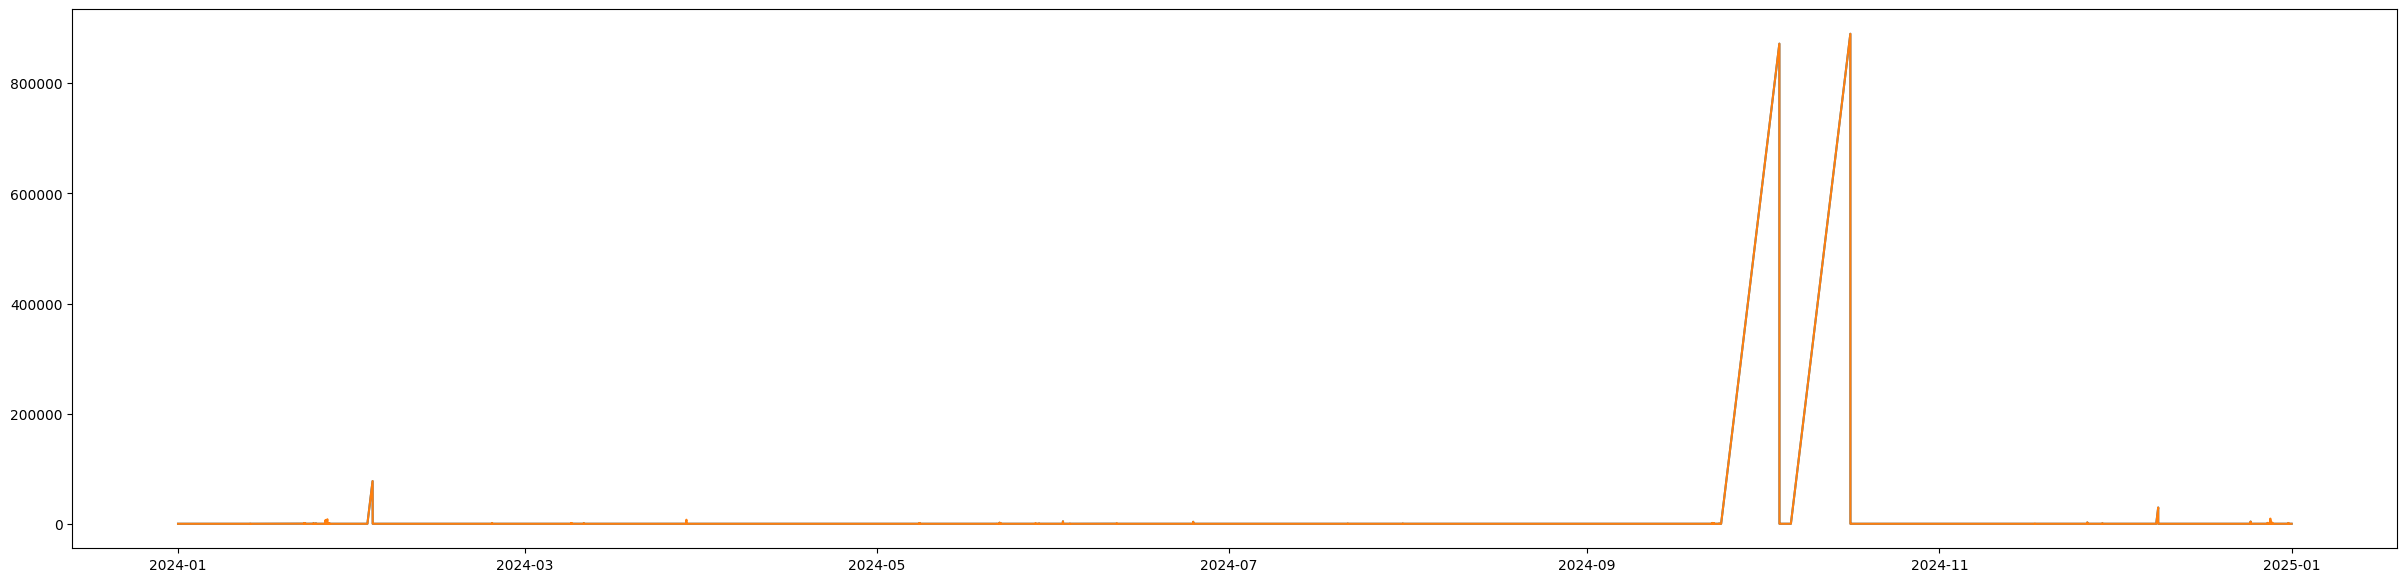

In [ ]:
# filter qid_mappings dict so that it only contains 2::0::6::1_1::1::0::2::0_1::0::1::0_8

# make for january only
start_time_january = pd.Timestamp(2024, 1, 1, tz='UTC')
end_time_january = pd.Timestamp(2024, 1, 31, 23, 59, 59, tz='UTC')

desired_qids = ['2::0::6::1_1::1::0::2::0_1::0::1::0_8']

desired_qid_mappings = qid_mappings_dict[qid_mappings_dict['qid_mapping'].isin(desired_qids)]

time_gaps_line_graph(df, desired_qid_mappings, start_time=start_time_january, end_time=end_time_january)

In [ ]:
# TODO: consider making first-order difference plots for single variables if necessary

In [ ]:
# TODO: check for synchronization on variables that should line up in time

## [Placeholder]